In [1]:
import pandas as pd 
import numpy as np

all_methods = ['kt_gaussian', 'iid', 'kt_matern', 'kt_sobolev', 'kt_inverse_multiquadric', 'kt_predictions', 'stein_thinning', 'arfpy', 'influence', 'kt_stratified']

# Figure 8

In [2]:
results_aggregated = pd.read_csv("../package_metadata/results_aggregation.csv")
all_methods = ['iid', 'kt_gaussian', 'stein_thinning', 'arfpy', 'influence']
results_aggregated = results_aggregated[results_aggregated['method_total'].isin(all_methods)]

metrics_to_analyze = [
    "mae_mean",
    "top_k_mean",
    "mmd_mean",
    "explanation_time_mean", 
    "mae_std",
    "top_k_std",
    "mmd_std",
    "explanation_time_std", 
    "compression_time_mean",
    "compression_time_std"
]

baseline_method = "iid"

results_with_improvements = results_aggregated.copy()

group_cols = ['dataset_name', 'model_name', 'explainer_total', 'size', 'task']

for group_name, group in results_aggregated.groupby(group_cols):
    dataset_name, model_name, explainer_total, size, task = group_name

    baseline_row = group[group['method_total'] == baseline_method]
    if baseline_row.empty:
        continue

    baseline_idx = baseline_row.index[0]

    # ---------- SET BASELINE REDUCTIONS TO 0 ----------
    for metric in metrics_to_analyze:
        if metric in results_aggregated.columns:
            results_with_improvements.loc[
                baseline_idx, f'{metric}_pct_reduction'
            ] = 0.0

    # ---------- OTHER METHODS ----------
    for method in all_methods:
        if method == baseline_method:
            continue

        method_rows = group[group['method_total'] == method]
        if method_rows.empty:
            continue

        for idx in method_rows.index:
            for metric in metrics_to_analyze:
                if metric not in results_aggregated.columns:
                    continue

                baseline_val = baseline_row[metric].values[0]
                method_val = results_aggregated.loc[idx, metric]

                if (
                    pd.isna(baseline_val)
                    or pd.isna(method_val)
                    or baseline_val == 0
                ):
                    results_with_improvements.loc[
                        idx, f'{metric}_pct_reduction'
                    ] = np.nan
                    continue

                pct_reduction = (
                    (baseline_val - method_val)
                    / baseline_val
                ) * 100

                results_with_improvements.loc[
                    idx, f'{metric}_pct_reduction'
                ] = pct_reduction


In [3]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ================== CONFIG ==================
output_root = "Image8"
palette = "GnBu"

metrics_to_analyze = [
    "mae_mean",
    "top_k_mean",
    "mmd_mean",
    "explanation_time_mean", 
    "mae_std",
    "top_k_std",
    "mmd_std",
    "explanation_time_std", 
    "compression_time_mean",
    "compression_time_std"
]

# ================== MEDIAN ANNOTATION ==================
def annotate_medians(ax, data, x, y, hue, palette):
    medians = (
        data
        .groupby([x, hue])[y]
        .median()
        .reset_index()
    )

    xticks = ax.get_xticks()
    xlabels = [t.get_text() for t in ax.get_xticklabels()]
    hue_levels = sorted(data[hue].dropna().unique())

    n_hue = len(hue_levels)
    width = 0.8
    step = width / n_hue

    colors = sns.color_palette(palette, n_hue)

    for _, row in medians.iterrows():
        x_pos = xlabels.index(row[x])
        hue_pos = hue_levels.index(row[hue])

        xpos = (
            xticks[x_pos]
            - width / 2
            + step / 2
            + hue_pos * step
        )

        r, g, b = colors[hue_pos]
        luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
        text_color = "white" if luminance < 0.5 else "black"

        ax.text(
            xpos,
            row[y],
            f"{row[y]:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color=text_color
        )

# ================== MAIN LOOP ==================
all_explainers = results_with_improvements["explainer_total"].unique()

os.makedirs(output_root, exist_ok=True)

for metric in metrics_to_analyze:
    metric_col = f"{metric}_pct_reduction"
    if metric_col not in results_with_improvements.columns:
        continue

    metric_dir = os.path.join(output_root, metric)
    os.makedirs(metric_dir, exist_ok=True)

    # ---- robust y-limits per metric ----
    q_low = results_with_improvements[metric_col].quantile(0.02)
    q_high = results_with_improvements[metric_col].quantile(0.98)
    padding = 0.05 * (q_high - q_low)

    y_min = q_low - padding
    y_max = 110

    for explainer in all_explainers:
        fig, axes = plt.subplots(2, 2, figsize=(20, 14))
        fig.suptitle(
            f"{metric} — Explainer: {explainer}",
            fontsize=18,
            fontweight="bold",
            y=1.02
        )

        for ax in axes.flat:
            ax.set_ylim(y_min, y_max)
            ax.axhline(0, linestyle="--", color="red", alpha=0.4)

        # ---------- NN - Regression ----------
        ax1 = axes[0, 0]
        data_nn_reg = results_with_improvements[
            (results_with_improvements["model_name"] == "nn") &
            (results_with_improvements["task"] == "regression") &
            (results_with_improvements["method_total"].isin(all_methods)) &
            (results_with_improvements["explainer_total"] == explainer)
        ]

        if not data_nn_reg.empty:
            sns.boxplot(
                data=data_nn_reg,
                x="method_total",
                y=metric_col,
                hue="compression_coefficient",
                ax=ax1,
                palette=palette
            )
            annotate_medians(
                ax1, data_nn_reg,
                "method_total", metric_col,
                "compression_coefficient", palette
            )

        ax1.set_title("NN - Regression")
        ax1.set_ylabel(f"{metric} % reduction")
        ax1.tick_params(axis="x", rotation=45)
        ax1.legend(title="Compression")

        # ---------- NN - Classification ----------
        ax2 = axes[0, 1]
        data_nn_clf = results_with_improvements[
            (results_with_improvements["model_name"] == "nn") &
            (results_with_improvements["task"] == "classification") &
            (results_with_improvements["method_total"].isin(all_methods)) &
            (results_with_improvements["explainer_total"] == explainer)
        ]

        if not data_nn_clf.empty:
            sns.boxplot(
                data=data_nn_clf,
                x="method_total",
                y=metric_col,
                hue="compression_coefficient",
                ax=ax2,
                palette=palette
            )
            annotate_medians(
                ax2, data_nn_clf,
                "method_total", metric_col,
                "compression_coefficient", palette
            )

        ax2.set_title("NN - Classification")
        ax2.set_ylabel("")
        ax2.tick_params(axis="x", rotation=45)
        ax2.legend(title="Compression")

        # ---------- XGBoost - Regression ----------
        ax3 = axes[1, 0]
        data_xgb_reg = results_with_improvements[
            (results_with_improvements["model_name"] == "xgboost") &
            (results_with_improvements["task"] == "regression") &
            (results_with_improvements["method_total"].isin(all_methods)) &
            (results_with_improvements["explainer_total"] == explainer)
        ]

        if not data_xgb_reg.empty:
            sns.boxplot(
                data=data_xgb_reg,
                x="method_total",
                y=metric_col,
                hue="compression_coefficient",
                ax=ax3,
                palette=palette
            )
            annotate_medians(
                ax3, data_xgb_reg,
                "method_total", metric_col,
                "compression_coefficient", palette
            )

        ax3.set_title("XGBoost - Regression")
        ax3.set_xlabel("Method")
        ax3.set_ylabel(f"{metric} % reduction")
        ax3.tick_params(axis="x", rotation=45)
        ax3.legend(title="Compression")

        # ---------- XGBoost - Classification ----------
        ax4 = axes[1, 1]
        data_xgb_clf = results_with_improvements[
            (results_with_improvements["model_name"] == "xgboost") &
            (results_with_improvements["task"] == "classification") &
            (results_with_improvements["method_total"].isin(all_methods)) &
            (results_with_improvements["explainer_total"] == explainer)
        ]

        if not data_xgb_clf.empty:
            sns.boxplot(
                data=data_xgb_clf,
                x="method_total",
                y=metric_col,
                hue="compression_coefficient",
                ax=ax4,
                palette=palette
            )
            annotate_medians(
                ax4, data_xgb_clf,
                "method_total", metric_col,
                "compression_coefficient", palette
            )

        ax4.set_title("XGBoost - Classification")
        ax4.set_xlabel("Method")
        ax4.set_ylabel("")
        ax4.tick_params(axis="x", rotation=45)
        ax4.legend(title="Compression")

        plt.tight_layout()

        fname = f"{explainer}.png"
        plt.savefig(os.path.join(metric_dir, fname), dpi=300, bbox_inches="tight")
        plt.close()


/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_35519/2895966634.py:188: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend(title="Compression")
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_35519/2895966634.py:218: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend(title="Compression")
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_35519/2895966634.py:188: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend(title="Compression")
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_35519/2895966634.py:218: UserWarning: No artists with labels found to put in 

# Figure 7

In [4]:
results_aggregated = pd.read_csv("../package_metadata/results_aggregation.csv")
all_methods = ['iid', 'kt_gaussian', 'kt_predictions']
results_aggregated = results_aggregated[results_aggregated['method_total'].isin(all_methods)]

metrics_to_analyze = [
    "mae_mean",
    "top_k_mean",
    "mmd_mean",
    "explanation_time_mean", 
    "mae_std",
    "top_k_std",
    "mmd_std",
    "explanation_time_std", 
    "compression_time_mean",
    "compression_time_std"
]

baseline_method = "iid"

results_with_improvements = results_aggregated.copy()

group_cols = ['dataset_name', 'model_name', 'explainer_total', 'size', 'task']

for group_name, group in results_aggregated.groupby(group_cols):
    dataset_name, model_name, explainer_total, size, task = group_name

    baseline_row = group[group['method_total'] == baseline_method]
    if baseline_row.empty:
        continue

    baseline_idx = baseline_row.index[0]

    # ---------- SET BASELINE REDUCTIONS TO 0 ----------
    for metric in metrics_to_analyze:
        if metric in results_aggregated.columns:
            results_with_improvements.loc[
                baseline_idx, f'{metric}_pct_reduction'
            ] = 0.0

    # ---------- OTHER METHODS ----------
    for method in all_methods:
        if method == baseline_method:
            continue

        method_rows = group[group['method_total'] == method]
        if method_rows.empty:
            continue

        for idx in method_rows.index:
            for metric in metrics_to_analyze:
                if metric not in results_aggregated.columns:
                    continue

                baseline_val = baseline_row[metric].values[0]
                method_val = results_aggregated.loc[idx, metric]

                if (
                    pd.isna(baseline_val)
                    or pd.isna(method_val)
                    or baseline_val == 0
                ):
                    results_with_improvements.loc[
                        idx, f'{metric}_pct_reduction'
                    ] = np.nan
                    continue

                pct_reduction = (
                    (baseline_val - method_val)
                    / baseline_val
                ) * 100

                results_with_improvements.loc[
                    idx, f'{metric}_pct_reduction'
                ] = pct_reduction


In [5]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ================== CONFIG ==================
output_root = "Image7"
palette = "GnBu"

metrics_to_analyze = [
    "mae_mean",
    "top_k_mean",
    "mmd_mean",
    "explanation_time_mean", 
    "mae_std",
    "top_k_std",
    "mmd_std",
    "explanation_time_std", 
    "compression_time_mean",
    "compression_time_std"
]

# ================== MEDIAN ANNOTATION ==================
def annotate_medians(ax, data, x, y, hue, palette):
    medians = (
        data
        .groupby([x, hue])[y]
        .median()
        .reset_index()
    )

    xticks = ax.get_xticks()
    xlabels = [t.get_text() for t in ax.get_xticklabels()]
    hue_levels = sorted(data[hue].dropna().unique())

    n_hue = len(hue_levels)
    width = 0.8
    step = width / n_hue

    colors = sns.color_palette(palette, n_hue)

    for _, row in medians.iterrows():
        x_pos = xlabels.index(row[x])
        hue_pos = hue_levels.index(row[hue])

        xpos = (
            xticks[x_pos]
            - width / 2
            + step / 2
            + hue_pos * step
        )

        r, g, b = colors[hue_pos]
        luminance = 0.2126 * r + 0.7152 * g + 0.0722 * b
        text_color = "white" if luminance < 0.5 else "black"

        ax.text(
            xpos,
            row[y],
            f"{row[y]:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color=text_color
        )

# ================== MAIN LOOP ==================
all_explainers = results_with_improvements["explainer_total"].unique()

os.makedirs(output_root, exist_ok=True)

for metric in metrics_to_analyze:
    metric_col = f"{metric}_pct_reduction"
    if metric_col not in results_with_improvements.columns:
        continue

    metric_dir = os.path.join(output_root, metric)
    os.makedirs(metric_dir, exist_ok=True)

    # ---- robust y-limits per metric ----
    q_low = results_with_improvements[metric_col].quantile(0.02)
    q_high = results_with_improvements[metric_col].quantile(0.98)
    padding = 0.05 * (q_high - q_low)

    y_min = q_low - padding
    y_max = 110

    for explainer in all_explainers:
        fig, axes = plt.subplots(2, 2, figsize=(20, 14))
        fig.suptitle(
            f"{metric} — Explainer: {explainer}",
            fontsize=18,
            fontweight="bold",
            y=1.02
        )

        for ax in axes.flat:
            ax.set_ylim(y_min, y_max)
            ax.axhline(0, linestyle="--", color="red", alpha=0.4)

        # ---------- NN - Regression ----------
        ax1 = axes[0, 0]
        data_nn_reg = results_with_improvements[
            (results_with_improvements["model_name"] == "nn") &
            (results_with_improvements["task"] == "regression") &
            (results_with_improvements["method_total"].isin(all_methods)) &
            (results_with_improvements["explainer_total"] == explainer)
        ]

        if not data_nn_reg.empty:
            sns.boxplot(
                data=data_nn_reg,
                x="method_total",
                y=metric_col,
                hue="compression_coefficient",
                ax=ax1,
                palette=palette
            )
            annotate_medians(
                ax1, data_nn_reg,
                "method_total", metric_col,
                "compression_coefficient", palette
            )

        ax1.set_title("NN - Regression")
        ax1.set_ylabel(f"{metric} % reduction")
        ax1.tick_params(axis="x", rotation=45)
        ax1.legend(title="Compression")

        # ---------- NN - Classification ----------
        ax2 = axes[0, 1]
        data_nn_clf = results_with_improvements[
            (results_with_improvements["model_name"] == "nn") &
            (results_with_improvements["task"] == "classification") &
            (results_with_improvements["method_total"].isin(all_methods)) &
            (results_with_improvements["explainer_total"] == explainer)
        ]

        if not data_nn_clf.empty:
            sns.boxplot(
                data=data_nn_clf,
                x="method_total",
                y=metric_col,
                hue="compression_coefficient",
                ax=ax2,
                palette=palette
            )
            annotate_medians(
                ax2, data_nn_clf,
                "method_total", metric_col,
                "compression_coefficient", palette
            )

        ax2.set_title("NN - Classification")
        ax2.set_ylabel("")
        ax2.tick_params(axis="x", rotation=45)
        ax2.legend(title="Compression")

        # ---------- XGBoost - Regression ----------
        ax3 = axes[1, 0]
        data_xgb_reg = results_with_improvements[
            (results_with_improvements["model_name"] == "xgboost") &
            (results_with_improvements["task"] == "regression") &
            (results_with_improvements["method_total"].isin(all_methods)) &
            (results_with_improvements["explainer_total"] == explainer)
        ]

        if not data_xgb_reg.empty:
            sns.boxplot(
                data=data_xgb_reg,
                x="method_total",
                y=metric_col,
                hue="compression_coefficient",
                ax=ax3,
                palette=palette
            )
            annotate_medians(
                ax3, data_xgb_reg,
                "method_total", metric_col,
                "compression_coefficient", palette
            )

        ax3.set_title("XGBoost - Regression")
        ax3.set_xlabel("Method")
        ax3.set_ylabel(f"{metric} % reduction")
        ax3.tick_params(axis="x", rotation=45)
        ax3.legend(title="Compression")

        # ---------- XGBoost - Classification ----------
        ax4 = axes[1, 1]
        data_xgb_clf = results_with_improvements[
            (results_with_improvements["model_name"] == "xgboost") &
            (results_with_improvements["task"] == "classification") &
            (results_with_improvements["method_total"].isin(all_methods)) &
            (results_with_improvements["explainer_total"] == explainer)
        ]

        if not data_xgb_clf.empty:
            sns.boxplot(
                data=data_xgb_clf,
                x="method_total",
                y=metric_col,
                hue="compression_coefficient",
                ax=ax4,
                palette=palette
            )
            annotate_medians(
                ax4, data_xgb_clf,
                "method_total", metric_col,
                "compression_coefficient", palette
            )

        ax4.set_title("XGBoost - Classification")
        ax4.set_xlabel("Method")
        ax4.set_ylabel("")
        ax4.tick_params(axis="x", rotation=45)
        ax4.legend(title="Compression")

        plt.tight_layout()

        fname = f"{explainer}.png"
        plt.savefig(os.path.join(metric_dir, fname), dpi=300, bbox_inches="tight")
        plt.close()


/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_35519/2934977726.py:188: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend(title="Compression")
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_35519/2934977726.py:218: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax4.legend(title="Compression")
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_35519/2934977726.py:188: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend(title="Compression")
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_35519/2934977726.py:218: UserWarning: No artists with labels found to put in 

# Figure 6

In [8]:
results_aggregated = pd.read_csv("../package_metadata/results_aggregation.csv")
all_methods = ['iid', 'kt_gaussian', 'kt_matern', 'kt_inverse_multiquadric']
results_aggregated = results_aggregated[results_aggregated['method_total'].isin(all_methods)]

metrics_to_analyze = [
    "mae_mean",
    "top_k_mean",
    "mmd_mean",
    "explanation_time_mean", 
    "mae_std",
    "top_k_std",
    "mmd_std",
    "explanation_time_std", 
    "compression_time_mean",
    "compression_time_std"
]

baseline_method = "iid"

results_with_improvements = results_aggregated.copy()

group_cols = ['dataset_name', 'model_name', 'explainer_total', 'size', 'task']

for group_name, group in results_aggregated.groupby(group_cols):
    dataset_name, model_name, explainer_total, size, task = group_name

    baseline_row = group[group['method_total'] == baseline_method]
    if baseline_row.empty:
        continue

    baseline_idx = baseline_row.index[0]

    # ---------- SET BASELINE REDUCTIONS TO 0 ----------
    for metric in metrics_to_analyze:
        if metric in results_aggregated.columns:
            results_with_improvements.loc[
                baseline_idx, f'{metric}_pct_reduction'
            ] = 0.0

    # ---------- OTHER METHODS ----------
    for method in all_methods:
        if method == baseline_method:
            continue

        method_rows = group[group['method_total'] == method]
        if method_rows.empty:
            continue

        for idx in method_rows.index:
            for metric in metrics_to_analyze:
                if metric not in results_aggregated.columns:
                    continue

                baseline_val = baseline_row[metric].values[0]
                method_val = results_aggregated.loc[idx, metric]

                if (
                    pd.isna(baseline_val)
                    or pd.isna(method_val)
                    or baseline_val == 0
                ):
                    results_with_improvements.loc[
                        idx, f'{metric}_pct_reduction'
                    ] = np.nan
                    continue

                pct_reduction = (
                    (baseline_val - method_val)
                    / baseline_val
                ) * 100

                results_with_improvements.loc[
                    idx, f'{metric}_pct_reduction'
                ] = pct_reduction


In [9]:
import matplotlib.pyplot as plt
import os

os.makedirs("Image6", exist_ok=True)

metrics_to_analyze = [
    "mae_mean",
    "top_k_mean",
    "mmd_mean",
    "explanation_time_mean", 
    "mae_std",
    "top_k_std",
    "mmd_std",
    "explanation_time_std", 
    "compression_time_mean",
    "compression_time_std"
]

tasks = ["regression", "classification"]

colors = {
    "regression": "#4E79A7",
    "classification": "#F2F2F2",
}

edgecolor = "#333333"
width = 0.35

for metric in metrics_to_analyze:
    pct_col = f"{metric}_pct_reduction"

    mean_improvement_by_config = (
        results_with_improvements[
            results_with_improvements["method_total"] != "iid"
        ]
        .groupby(["task", "model_name", "explainer_total"])[[pct_col]]
        .mean()
        .mean(axis=1)
        .reset_index(name="mean_improvement_not_iid")
    )

    df = mean_improvement_by_config.copy()

    explainers = df["explainer_total"].unique()
    models = df["model_name"].unique()

    fig, axes = plt.subplots(2, 2, sharey=True, figsize=(12, 8))
    axes = axes.flatten()

    for ax, explainer in zip(axes, explainers):
        sub = df[df["explainer_total"] == explainer]
        x = range(len(models))

        for i, task in enumerate(tasks):
            task_sub = sub[sub["task"] == task]

            values = [
                task_sub.loc[
                    task_sub["model_name"] == model,
                    "mean_improvement_not_iid",
                ].values[0]
                if model in task_sub["model_name"].values
                else 0
                for model in models
            ]

            bars = ax.bar(
                [xi + i * width for xi in x],
                values,
                width,
                label=task.capitalize(),
                color=colors[task],
                edgecolor=edgecolor,
                linewidth=1.0,
            )

            for bar in bars:
                h = bar.get_height()
                if h > 0:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        h + 1.5,
                        f"{h:.1f}",
                        ha="center",
                        va="bottom",
                        fontsize=12,
                    )

        ax.set_title(f"Explainer: {explainer}", fontsize=14)
        ax.set_xticks([xi + width / 2 for xi in x])
        ax.set_xticklabels(models, fontsize=12)
        ax.set_ylim(0, 100)
        ax.grid(axis="y", linestyle="--", alpha=0.5)
        ax.set_ylabel("Mean % improvement vs IID", fontsize=12)

    axes[0].legend(frameon=False, fontsize=12)
    fig.suptitle(f"{metric} improvement vs IID", fontsize=16, y=1.02)
    plt.tight_layout()
    
    plt.savefig(f"Image9/{metric}_improvement.png", dpi=300, bbox_inches="tight")
    plt.close(fig)


# Image 9

In [2]:
results_aggregated = pd.read_csv("../package_metadata/results_aggregation.csv")
all_methods = ['iid', 'kt_gaussian', 'kt_matern', 'kt_inverse_multiquadric']
results_aggregated = results_aggregated[results_aggregated['method_total'].isin(all_methods)]

metrics_to_analyze = [
    "mae_mean",
    "top_k_mean",
    "mmd_mean",
    "explanation_time_mean", 
    "mae_std",
    "top_k_std",
    "mmd_std",
    "explanation_time_std", 
    "compression_time_mean",
    "compression_time_std"
]

baseline_method = "iid"

results_with_improvements = results_aggregated.copy()

group_cols = ['dataset_name', 'model_name', 'explainer_total', 'size', 'task']

for group_name, group in results_aggregated.groupby(group_cols):
    dataset_name, model_name, explainer_total, size, task = group_name

    baseline_row = group[group['method_total'] == baseline_method]
    if baseline_row.empty:
        continue

    baseline_idx = baseline_row.index[0]

    # ---------- SET BASELINE REDUCTIONS TO 0 ----------
    for metric in metrics_to_analyze:
        if metric in results_aggregated.columns:
            results_with_improvements.loc[
                baseline_idx, f'{metric}_pct_reduction'
            ] = 0.0

    # ---------- OTHER METHODS ----------
    for method in all_methods:
        if method == baseline_method:
            continue

        method_rows = group[group['method_total'] == method]
        if method_rows.empty:
            continue

        for idx in method_rows.index:
            for metric in metrics_to_analyze:
                if metric not in results_aggregated.columns:
                    continue

                baseline_val = baseline_row[metric].values[0]
                method_val = results_aggregated.loc[idx, metric]

                if (
                    pd.isna(baseline_val)
                    or pd.isna(method_val)
                    or baseline_val == 0
                ):
                    results_with_improvements.loc[
                        idx, f'{metric}_pct_reduction'
                    ] = np.nan
                    continue

                pct_reduction = (
                    (baseline_val - method_val)
                    / baseline_val
                ) * 100

                results_with_improvements.loc[
                    idx, f'{metric}_pct_reduction'
                ] = pct_reduction


In [4]:
import matplotlib.pyplot as plt
import os

output_dir = "./Image9"
os.makedirs(output_dir, exist_ok=True)

metrics_to_analyze = [
    "mae_mean",
    "top_k_mean",
    "mmd_mean",
    "explanation_time_mean", 
    "mae_std",
    "top_k_std",
    "mmd_std",
    "explanation_time_std", 
    "compression_time_mean",
    "compression_time_std"
]

tasks = ["regression", "classification"]

colors = {
    "regression": "#4E79A7",
    "classification": "#F2F2F2",
}

edgecolor = "#333333"
width = 0.35

for metric in metrics_to_analyze:
    pct_col = f"{metric}_pct_reduction"

    mean_improvement_by_config = (
        results_with_improvements[
            results_with_improvements["method_total"] != "iid"
        ]
        .groupby(["task", "model_name", "explainer_total"])[[pct_col]]
        .mean()
        .mean(axis=1)
        .reset_index(name="mean_improvement_not_iid")
    )

    df = mean_improvement_by_config.copy()

    explainers = df["explainer_total"].unique()
    models = df["model_name"].unique()

    fig, axes = plt.subplots(2, 2, sharey=True, figsize=(12, 8))
    axes = axes.flatten()

    for ax, explainer in zip(axes, explainers):
        sub = df[df["explainer_total"] == explainer]
        x = range(len(models))

        for i, task in enumerate(tasks):
            task_sub = sub[sub["task"] == task]

            values = [
                task_sub.loc[
                    task_sub["model_name"] == model,
                    "mean_improvement_not_iid",
                ].values[0]
                if model in task_sub["model_name"].values
                else 0
                for model in models
            ]

            bars = ax.bar(
                [xi + i * width for xi in x],
                values,
                width,
                label=task.capitalize(),
                color=colors[task],
                edgecolor=edgecolor,
                linewidth=1.0,
            )

            for bar in bars:
                h = bar.get_height()
                if h > 0:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        h + 1.5,
                        f"{h:.1f}",
                        ha="center",
                        va="bottom",
                        fontsize=12,
                    )

        ax.set_title(f"Explainer: {explainer}", fontsize=14)
        ax.set_xticks([xi + width / 2 for xi in x])
        ax.set_xticklabels(models, fontsize=12)
        if metric in ["mae_mean", "mae_std", "top_k_std", "mmd_mean"]:
            ax.set_ylim(0, 110)
        if metric in ["top_k_mean"]:
            ax.set_ylim(-100, 0)
        ax.grid(axis="y", linestyle="--", alpha=0.5)
        ax.set_ylabel("Mean % reduction vs IID", fontsize=12)

    axes[0].legend(frameon=False, fontsize=12)
    fig.suptitle(f"{metric} reduction vs IID", fontsize=16, y=1.02)
    plt.tight_layout()

    plt.savefig(f"Image9/{metric}_reduction.png", dpi=300, bbox_inches="tight")
    plt.close(fig)


In [5]:
import matplotlib.pyplot as plt
import os
import math

output_dir = "./Image10"
os.makedirs(output_dir, exist_ok=True)

metrics_to_analyze = [
    "mae_mean",
    "top_k_mean",
    "mmd_mean",
    "explanation_time_mean", 
    "mae_std",
    "top_k_std",
    "mmd_std",
    "explanation_time_std", 
    "compression_time_mean",
    "compression_time_std"
]
methods_to_plot = ["kt_gaussian", "kt_matern", "kt_inverse_multiquadric"]
tasks = ["regression", "classification"]

colors = {
    "regression": "#4E79A7",
    "classification": "#F2F2F2",
}

edgecolor = "#333333"
width = 0.25
y_margin = 5

for metric in metrics_to_analyze:
    pct_col = f"{metric}_pct_reduction"

    dfs = []
    for method in methods_to_plot:
        df_method = (
            results_with_improvements[
                results_with_improvements["method_total"] == method
            ]
            .groupby(["task", "model_name", "explainer_total"])[[pct_col]]
            .mean()
            .mean(axis=1)
            .reset_index(name="mean_improvement")
        )
        df_method["method_total"] = method
        dfs.append(df_method)

    df_all = pd.concat(dfs, ignore_index=True)
    explainers = df_all["explainer_total"].unique()
    models = df_all["model_name"].unique()

    all_values = df_all["mean_improvement"].values
    y_min = min(all_values) - y_margin
    y_max = max(all_values) + y_margin

    n_subplots = len(explainers) * len(methods_to_plot)
    n_cols = 4
    n_rows = math.ceil(n_subplots / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*4), sharey=True)
    axes = axes.flatten()

    for idx, (method, explainer) in enumerate([(m, e) for m in methods_to_plot for e in explainers]):
        ax = axes[idx]
        sub = df_all[(df_all["explainer_total"] == explainer) & (df_all["method_total"] == method)]
        x = range(len(models))

        for i, task in enumerate(tasks):
            task_sub = sub[sub["task"] == task]
            values = [
                task_sub.loc[
                    task_sub["model_name"] == model,
                    "mean_improvement",
                ].values[0]
                if model in task_sub["model_name"].values
                else 0
                for model in models
            ]

            bars = ax.bar(
                [xi + i * width for xi in x],
                values,
                width,
                label=task.capitalize(),
                color=colors[task],
                edgecolor=edgecolor,
                linewidth=1.0,
            )

            for bar in bars:
                h = bar.get_height()
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    h + (1 if h >= 0 else -3),
                    f"{h:.1f}",
                    ha="center",
                    va="bottom" if h >= 0 else "top",
                    fontsize=10,
                )

        ax.set_title(f"{method} — {explainer}", fontsize=12)
        ax.set_xticks([xi + width / 2 for xi in x])
        ax.set_xticklabels(models, fontsize=10)
        ax.set_ylim(y_min, y_max)
        ax.grid(axis="y", linestyle="--", alpha=0.5)
        ax.set_ylabel("Mean % reduction vs IID", fontsize=10)

    for j in range(idx+1, len(axes)):
        fig.delaxes(axes[j])

    axes[0].legend(frameon=False, fontsize=10)
    fig.suptitle(f"{metric} reduction vs IID", fontsize=16, y=1.02)
    plt.tight_layout()

    plt.savefig(f"{output_dir}/{metric}_all_methods_reduction.png", dpi=300, bbox_inches="tight")
    plt.close(fig)


/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_47572/4127293950.py:114: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_47572/4127293950.py:114: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


# Image 11

In [6]:
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

# run cell below "Image 9"

output_dir = "./Image11"
os.makedirs(output_dir, exist_ok=True)

metrics_to_analyze = [
    "mae_mean",
    "top_k_mean",
    "mmd_mean",
    "explanation_time_mean", 
    "mae_std",
    "top_k_std",
    "mmd_std",
    "explanation_time_std", 
    "compression_time_mean",
    "compression_time_std"
]

methods_to_plot = ["kt_gaussian", "kt_matern", "kt_inverse_multiquadric", "kt_sobolev"]
tasks = ["regression", "classification"]

method_colors = {
    "kt_gaussian": "#4E79A7",
    "kt_matern": "#59A14F",
    "kt_inverse_multiquadric": "#F28E2B",
    "kt_sobolev": "#E15759",
}

task_hatch = {
    "regression": None,
    "classification": "//",
}

method_labels = {
    "kt_gaussian": "KT (Gaussian)",
    "kt_matern": "KT (Matérn)",
    "kt_inverse_multiquadric": "KT (Inv. Multiquadric)",
    "kt_sobolev": "KT (Sobolev)",
}

explainer_labels = {
    "expected_gradients": "Expected Gradients",
    "sage_permutation": "SAGE (Permutation)",
    "shap_kernel": "SHAP (Kernel)",
    "shapiq_kernel": "SHAP-IQ (Kernel)",
}

metric_titles = {
    "mae_mean": "MAE (mean)",
    "top_k_mean": "Top-k agreement (mean)",
    "mmd_mean": "MMD (mean)",
    "explanation_time_mean": "Explanation time (mean)",
    "mae_std": "MAE (std)",
    "top_k_std": "Top-k agreement (std)",
    "mmd_std": "MMD (std)",
    "explanation_time_std": "Explanation time (std)",
}

# Only top_k_mean uses "improvement" (higher is better)
metric_ylabels = {
    "mae_mean": "Mean % MAE reduction vs IID",
    "top_k_mean": "Mean % Top-k improvement vs IID",
    "mmd_mean": "Mean % MMD reduction vs IID",
    "explanation_time_mean": "Mean % time reduction vs IID",
    "mae_std": "Std % MAE reduction vs IID",
    "top_k_std": "Std % Top-k reduction vs IID",
    "mmd_std": "Std % MMD reduction vs IID",
    "explanation_time_std": "Std % time reduction vs IID",
}

edgecolor = "#333333"
y_margin = 5

# Formatting controls for bar labels
zero_tol = 1e-12        # treat values with abs(v) <= zero_tol as zero -> no label
label_min_abs = 0.05    # don't label tiny bars (helps readability); set 0.0 to label all nonzero

for metric in metrics_to_analyze:
    pct_col = f"{metric}_pct_reduction"

    # Flip sign only for top_k_mean (so higher is better)
    flip_sign = (metric == "top_k_mean")
    is_std = metric.endswith("_std")

    dfs = []
    for method in methods_to_plot:
        df_method = (
            results_with_improvements[results_with_improvements["method_total"] == method]
            .groupby(["task", "model_name", "explainer_total"])[[pct_col]]
            .mean()
            .mean(axis=1)
            .reset_index(name="mean_improvement")
        )
        df_method["method_total"] = method
        dfs.append(df_method)

    df_all = pd.concat(dfs, ignore_index=True)

    # Stable 1x4 explainer order (only those present)
    explainer_order = list(explainer_labels.keys())
    explainers = [e for e in explainer_order if e in df_all["explainer_total"].unique()]
    models = sorted(df_all["model_name"].unique())

    # Apply sign flip to aggregated values (only for top_k_mean)
    if flip_sign:
        df_all["mean_improvement"] = -df_all["mean_improvement"]

    all_vals = df_all["mean_improvement"].values
    y_min, y_max = float(np.min(all_vals))*0.90, float(np.max(all_vals))*1.1 #float(np.min(all_vals)) - y_margin, float(np.max(all_vals)) + y_margin

    # 1x4 layout; make std plots larger (they often have small magnitudes)
    fig_w = len(explainers) * (9.5 if is_std else 8.5)
    fig_h = 7.5 if is_std else 6.5

    fig, axes = plt.subplots(
        1,
        len(explainers),
        figsize=(fig_w, fig_h),
        sharey=True,
    )
    if len(explainers) == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Bars: methods * tasks per model
    bar_group_width = 0.90 if is_std else 0.82
    bar_w = bar_group_width / (len(methods_to_plot) * len(tasks))

    for idx, explainer in enumerate(explainers):
        ax = axes[idx]
        sub = df_all[df_all["explainer_total"] == explainer]

        x = np.arange(len(models))
        bar_i = 0

        for method in methods_to_plot:
            for task in tasks:
                task_sub = sub[(sub["method_total"] == method) & (sub["task"] == task)]

                values = [
                    float(task_sub.loc[task_sub["model_name"] == m, "mean_improvement"].values[0])
                    if m in task_sub["model_name"].values
                    else 0.0
                    for m in models
                ]

                offsets = (bar_i - (len(methods_to_plot) * len(tasks) - 1) / 2) * bar_w
                xpos = x + offsets

                bars = ax.bar(
                    xpos,
                    values,
                    width=bar_w,
                    color=method_colors[method],
                    edgecolor=edgecolor,
                    hatch=task_hatch[task],
                    linewidth=1.1,
                )

                # Always show labels (including std), but never show 0.0 labels
                for b in bars:
                    h = float(b.get_height())
                    if abs(h) <= zero_tol or abs(h) < label_min_abs:
                        continue
                    ax.text(
                        b.get_x() + b.get_width() / 2,
                        h + (1 if h >= 0 else -3),
                        f"{h:.1f}",
                        ha="center",
                        va="bottom" if h >= 0 else "top",
                        fontsize=9, 
                    )

                bar_i += 1

        ax.set_title(explainer_labels.get(explainer, explainer), fontsize=14)
        ax.set_xticks(x)
        ax.set_xticklabels(models, fontsize=11)
        ax.set_ylim(y_min, y_max)
        ax.grid(axis="y", linestyle="--", alpha=0.5)

        if idx == 0:
            ax.set_ylabel(metric_ylabels.get(metric, "Mean % change vs IID"), fontsize=12)

    # Legend: methods (colors) + tasks (hatches)
    method_handles = [
        Patch(facecolor=method_colors[m], edgecolor=edgecolor, label=method_labels[m])
        for m in methods_to_plot
    ]
    task_handles = [
        Patch(facecolor="white", edgecolor=edgecolor, hatch=task_hatch[t], label=t.capitalize())
        for t in tasks
    ]

    axes[0].legend(
        handles=method_handles + task_handles,
        frameon=False,
        fontsize=11,
        loc="upper right",
    )

    # Title: make top_k_mean wording consistent with sign flip
    title = metric_titles.get(metric, metric)
    if metric == "top_k_mean":
        title += " (higher is better)"

    fig.suptitle(f"Kernel choice in Kernel Thinning — {title}", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{metric}_1x4_combined_methods.png", dpi=300, bbox_inches="tight")
    plt.close(fig)


# Image 13

In [4]:
results_aggregated = pd.read_csv("../package_metadata/results_strat_aggregation.csv")
all_methods = ['iid', 'kt_gaussian', "kt_stratified", "kt_predictions"]
results_aggregated = results_aggregated[results_aggregated['method_total'].isin(all_methods)]

metrics_to_analyze = [
    "mae_mean",
    "top_k_mean",
    "mmd_mean",
    "explanation_time_mean", 
    "mae_std",
    "top_k_std",
    "mmd_std",
    "explanation_time_std", 
    "compression_time_mean",
    "compression_time_std"
]

baseline_method = "iid"

results_with_improvements = results_aggregated.copy()

group_cols = ['dataset_name', 'model_name', 'explainer_total', 'target_size', 'task']

for group_name, group in results_aggregated.groupby(group_cols):
    dataset_name, model_name, explainer_total, size, task = group_name

    baseline_row = group[group['method_total'] == baseline_method]
    if baseline_row.empty:
        continue

    baseline_idx = baseline_row.index[0]

    # ---------- SET BASELINE REDUCTIONS TO 0 ----------
    for metric in metrics_to_analyze:
        if metric in results_aggregated.columns:
            results_with_improvements.loc[
                baseline_idx, f'{metric}_pct_reduction'
            ] = 0.0

    # ---------- OTHER METHODS ----------
    for method in all_methods:
        if method == baseline_method:
            continue

        method_rows = group[group['method_total'] == method]
        if method_rows.empty:
            continue

        for idx in method_rows.index:
            for metric in metrics_to_analyze:
                if metric not in results_aggregated.columns:
                    continue

                baseline_val = baseline_row[metric].values[0]
                method_val = results_aggregated.loc[idx, metric]

                if (
                    pd.isna(baseline_val)
                    or pd.isna(method_val)
                    or baseline_val == 0
                ):
                    results_with_improvements.loc[
                        idx, f'{metric}_pct_reduction'
                    ] = np.nan
                    continue

                pct_reduction = (
                    (baseline_val - method_val)
                    / baseline_val
                ) * 100

                results_with_improvements.loc[
                    idx, f'{metric}_pct_reduction'
                ] = pct_reduction


In [8]:
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

output_dir = "./Image13"
os.makedirs(output_dir, exist_ok=True)

metrics_to_analyze = [
    "mae_mean",
    "top_k_mean",
    "mmd_mean",
    "explanation_time_mean", 
    "mae_std",
    "top_k_std",
    "mmd_std",
    "explanation_time_std", 
    "compression_time_mean",
    "compression_time_std"
]

methods_to_plot = ["kt_gaussian", "kt_predictions", "kt_stratified"]
tasks = ["regression", "classification"]

method_colors = {
    "kt_gaussian": "#4E79A7",
    "kt_stratified": "#5eb38a",
    "kt_predictions": "#f08060"
}

task_hatch = {
    "regression": None,
    "classification": "//",
}

method_labels = {
    "kt_gaussian": "KT (Gaussian)",
    "kt_stratified": "KT Stratified",
    "kt_predictions": "KT Predictions",
}

explainer_labels = {
    "expected_gradients": "Expected Gradients",
    "sage_permutation": "SAGE (Permutation)",
    "shap_kernel": "SHAP (Kernel)",
    "shapiq_kernel": "SHAP-IQ (Kernel)",
}

metric_titles = {
    "mae_mean": "MAE (mean)",
    "top_k_mean": "Top-k agreement (mean)",
    "mmd_mean": "MMD (mean)",
    "explanation_time_mean": "Explanation time (mean)",
    "mae_std": "MAE (std)",
    "top_k_std": "Top-k agreement (std)",
    "mmd_std": "MMD (std)",
    "explanation_time_std": "Explanation time (std)",
}

metric_ylabels = {
    "mae_mean": "Mean % MAE reduction vs IID",
    "top_k_mean": "Mean % Top-k improvement vs IID",
    "mmd_mean": "Mean % MMD reduction vs IID",
    "explanation_time_mean": "Mean % time reduction vs IID",
    "mae_std": "Std % MAE reduction vs IID",
    "top_k_std": "Std % Top-k reduction vs IID",
    "mmd_std": "Std % MMD reduction vs IID",
    "explanation_time_std": "Std % time reduction vs IID",
}

edgecolor = "#333333"
zero_tol = 1e-12
label_min_abs = 0.05

for metric in metrics_to_analyze:
    pct_col = f"{metric}_pct_reduction"
    flip_sign = (metric == "top_k_mean")
    is_std = metric.endswith("_std")

    dfs = []
    for method in methods_to_plot:
        temp_df = results_with_improvements[results_with_improvements["method_total"] == method]
        if temp_df.empty:
            continue
            
        df_method = (
            temp_df.groupby(["task", "model_name", "explainer_total"])[[pct_col]]
            .mean()
            .mean(axis=1)
            .reset_index(name="mean_improvement")
        )
        df_method["method_total"] = method
        dfs.append(df_method)

    df_all = pd.concat(dfs, ignore_index=True)

    explainer_order = list(explainer_labels.keys())
    explainers = [e for e in explainer_order if e in df_all["explainer_total"].unique()]
    models = sorted(df_all["model_name"].unique())

    if flip_sign:
        df_all["mean_improvement"] = -df_all["mean_improvement"]

    all_vals = df_all["mean_improvement"].values
    y_min, y_max = float(np.min(all_vals))*0.90, float(np.max(all_vals))*1.1

    fig_w = len(explainers) * (9.5 if is_std else 8.5)
    fig_h = 7.5 if is_std else 6.5

    fig, axes = plt.subplots(1, len(explainers), figsize=(fig_w, fig_h), sharey=True)
    if len(explainers) == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    group_spacing = 0.15
    bar_w = 0.12

    for idx, explainer in enumerate(explainers):
        ax = axes[idx]
        sub = df_all[df_all["explainer_total"] == explainer]
        x = np.arange(len(models))

        for t_idx, task in enumerate(tasks):
            available_methods = sub[sub["task"] == task]["method_total"].unique()
            current_methods = [m for m in methods_to_plot if m in available_methods]
            
            task_offset = (t_idx - (len(tasks)-1)/2) * (len(methods_to_plot) * bar_w + group_spacing)
            
            for m_idx, method in enumerate(current_methods):
                task_sub = sub[(sub["method_total"] == method) & (sub["task"] == task)]
                if task_sub.empty:
                    continue

                values = [
                    float(task_sub.loc[task_sub["model_name"] == m, "mean_improvement"].values[0])
                    if m in task_sub["model_name"].values
                    else 0.0
                    for m in models
                ]

                method_offset = (m_idx - (len(current_methods)-1)/2) * bar_w
                xpos = x + task_offset + method_offset

                bars = ax.bar(
                    xpos,
                    values,
                    width=bar_w,
                    color=method_colors[method],
                    edgecolor=edgecolor,
                    hatch=task_hatch[task],
                    linewidth=1.1,
                )

                for b in bars:
                    h = float(b.get_height())
                    if abs(h) <= zero_tol or abs(h) < label_min_abs:
                        continue
                    ax.text(
                        b.get_x() + b.get_width() / 2,
                        h + (0.5 if h >= 0 else -0.5),
                        f"{h:.1f}",
                        ha="center",
                        va="bottom" if h >= 0 else "top",
                        fontsize=14
                    )

        ax.set_title(explainer_labels.get(explainer, explainer), fontsize=14)
        ax.set_xticks(x)
        ax.set_xticklabels(models, fontsize=11)
        ax.set_ylim(y_min, 105)
        ax.grid(axis="y", linestyle="--", alpha=0.5)

        if idx == 0:
            ax.set_ylabel(metric_ylabels.get(metric, "Mean % change vs IID"), fontsize=12)

    method_handles = [
        Patch(facecolor=method_colors[m], edgecolor=edgecolor, label=method_labels[m])
        for m in methods_to_plot
    ]
    task_handles = [
        Patch(facecolor="white", edgecolor=edgecolor, hatch=task_hatch[t], label=t.capitalize())
        for t in tasks
    ]

    axes[-1].legend(
        handles=method_handles + task_handles,
        frameon=False,
        fontsize=10,
        loc="upper left",
        bbox_to_anchor=(1.02, 1)
    )

    title = metric_titles.get(metric, metric)
    if metric == "top_k_mean":
        title += " (higher is better)"

    fig.suptitle(f"Kernel choice in Kernel Thinning — {title}", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{metric}_1x4_task_grouped.png", dpi=300, bbox_inches="tight")
    plt.close(fig)

# Image 14

In [2]:
results_aggregated = pd.read_csv("../package_metadata/results_strat_aggregation.csv")
all_methods = ['kt_gaussian', 'iid', 'kt_matern', 'kt_sobolev', 'kt_inverse_multiquadric', 'kt_predictions', 'stein_thinning', 'arfpy', 'influence', 'kt_stratified']
results_aggregated = results_aggregated[results_aggregated['method_total'].isin(all_methods)]

metrics_to_analyze = [
    "mae_mean",
    "top_k_mean",
    "mmd_mean",
    "explanation_time_mean", 
    "mae_std",
    "top_k_std",
    "mmd_std",
    "explanation_time_std", 
    "compression_time_mean",
    "compression_time_std"
]



baseline_method = "iid"

results_with_improvements = results_aggregated.copy()

group_cols = ['dataset_name', 'model_name', 'explainer_total', 'target_size', 'task']

for group_name, group in results_aggregated.groupby(group_cols):
    dataset_name, model_name, explainer_total, size, task = group_name

    baseline_row = group[group['method_total'] == baseline_method]
    if baseline_row.empty:
        continue

    baseline_idx = baseline_row.index[0]

    # ---------- SET BASELINE REDUCTIONS TO 0 ----------
    for metric in metrics_to_analyze:
        if metric in results_aggregated.columns:
            results_with_improvements.loc[
                baseline_idx, f'{metric}_pct_reduction'
            ] = 0.0

    # ---------- OTHER METHODS ----------
    for method in all_methods:
        if method == baseline_method:
            continue

        method_rows = group[group['method_total'] == method]
        if method_rows.empty:
            continue

        for idx in method_rows.index:
            for metric in metrics_to_analyze:
                if metric not in results_aggregated.columns:
                    continue

                baseline_val = baseline_row[metric].values[0]
                method_val = results_aggregated.loc[idx, metric]

                if (
                    pd.isna(baseline_val)
                    or pd.isna(method_val)
                    or baseline_val == 0
                ):
                    results_with_improvements.loc[
                        idx, f'{metric}_pct_reduction'
                    ] = np.nan
                    continue

                pct_reduction = (
                    (baseline_val - method_val)
                    / baseline_val
                ) * 100

                results_with_improvements.loc[
                    idx, f'{metric}_pct_reduction'
                ] = pct_reduction


In [3]:
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from itertools import cycle

output_dir = "./Image14"
os.makedirs(output_dir, exist_ok=True)

metrics_to_analyze = [
    "mae_mean",
    "top_k_mean",
    "mmd_mean",
    "explanation_time_mean",
    "mae_std",
    "top_k_std",
    "mmd_std",
    "explanation_time_std",
]

methods_to_plot = [
    # 'kt_gaussian', 'kt_matern', 'kt_inverse_multiquadric', 'kt_stratified',
    'kt_matern', 'stein_thinning', 'arfpy', 'influence',
]

tasks = ["regression", "classification"]

# ---------- COLORS: auto-generate ----------
palette = plt.get_cmap("tab10")
method_colors = {
    m: palette(i % palette.N) for i, m in enumerate(methods_to_plot)
}

method_colors = {
    "kt_matern": "#59A14F",
    "arfpy": "#FF7DB0",
    "stein_thinning":"#B8DB80",
    "influence":"#5459AC",
    "iid": "#1F51FF",
}

# ---------- LABELS: readable defaults ----------
def prettify_method(m):
    return m.replace("_", " ").replace("kt", "KT").title()

method_labels = {m: prettify_method(m) for m in methods_to_plot}

# Optional overrides (keep nice names where needed)
method_labels.update({
    "kt_gaussian": "KT (Gaussian)",
    "kt_matern": "KT (Matérn)",
    "kt_inverse_multiquadric": "KT (Inv. Multiquadric)",
    "kt_predictions": "KT (Predictions)",
    "kt_stratified": "KT (Stratified)",
    "arfpy": "ARF",
})

task_hatch = {
    "regression": None,
    "classification": "//",
}

explainer_labels = {
    "expected_gradients": "Expected Gradients",
    "sage_permutation": "SAGE (Permutation)",
    "shap_kernel": "SHAP (Kernel)",
    "shapiq_kernel": "SHAP-IQ (Kernel)",
}

metric_titles = {
    "mae_mean": "MAE (mean)",
    "top_k_mean": "Top-k agreement (mean)",
    "mmd_mean": "MMD (mean)",
    "explanation_time_mean": "Explanation time (mean)",
    "mae_std": "MAE (std)",
    "top_k_std": "Top-k agreement (std)",
    "mmd_std": "MMD (std)",
    "explanation_time_std": "Explanation time (std)",
}

metric_ylabels = {
    "mae_mean": "Mean % MAE reduction vs IID",
    "top_k_mean": "Mean % Top-k improvement vs IID",
    "mmd_mean": "Mean % MMD reduction vs IID",
    "explanation_time_mean": "Mean % time reduction vs IID",
    "mae_std": "Std % MAE reduction vs IID",
    "top_k_std": "Std % Top-k change vs IID",
    "mmd_std": "Std % MMD reduction vs IID",
    "explanation_time_std": "Std % time reduction vs IID",
}

edgecolor = "#333333"
zero_tol = 1e-12
label_min_abs = 0.05

for metric in metrics_to_analyze:
    pct_col = f"{metric}_pct_reduction"
    flip_sign = (metric == "top_k_mean")
    is_std = metric.endswith("_std")

    dfs = []
    for method in methods_to_plot:
        sub = results_with_improvements[
            results_with_improvements["method_total"] == method
        ]
        if sub.empty:
            continue

        df_method = (
            sub.groupby(["task", "model_name", "explainer_total"])[[pct_col]]
            .mean()
            .mean(axis=1)
            .reset_index(name="mean_improvement")
        )
        df_method["method_total"] = method
        dfs.append(df_method)

    if not dfs:
        continue

    df_all = pd.concat(dfs, ignore_index=True)

    if flip_sign:
        df_all["mean_improvement"] *= -1

    explainers = [
        e for e in explainer_labels
        if e in df_all["explainer_total"].unique()
    ]
    models = sorted(df_all["model_name"].unique())

    vals = df_all["mean_improvement"].values
    y_min = min(0, np.min(vals) * 0.9)
    y_max = np.max(vals) * 1.1

    fig_w = len(explainers) * (9.5 if is_std else 8.5)
    fig_h = 7.5 if is_std else 6.5

    fig, axes = plt.subplots(1, len(explainers), figsize=(fig_w, fig_h), sharey=True)
    axes = np.atleast_1d(axes).flatten()

    bar_group_width = 0.90 if is_std else 0.82
    bar_w = bar_group_width / (len(methods_to_plot) * len(tasks))

    for i, explainer in enumerate(explainers):
        ax = axes[i]
        sub = df_all[df_all["explainer_total"] == explainer]

        x = np.arange(len(models))
        bar_i = 0

        for method in methods_to_plot:
            for task in tasks:
                tmp = sub[(sub["method_total"] == method) & (sub["task"] == task)]
                values = [
                    tmp.loc[tmp["model_name"] == m, "mean_improvement"].values[0]
                    if m in tmp["model_name"].values else 0.0
                    for m in models
                ]

                xpos = x + (bar_i - (len(methods_to_plot)*len(tasks)-1)/2) * bar_w

                bars = ax.bar(
                    xpos, values, bar_w,
                    color=method_colors[method],
                    hatch=task_hatch[task],
                    edgecolor=edgecolor,
                    linewidth=1.0,
                )

                for b in bars:
                    h = b.get_height()
                    if abs(h) <= zero_tol or abs(h) < label_min_abs:
                        continue
                    ax.text(
                        b.get_x() + b.get_width()/2,
                        h + (1 if h >= 0 else -3),
                        f"{h:.1f}",
                        ha="center",
                        va="bottom" if h >= 0 else "top",
                        fontsize=9,
                    )

                bar_i += 1

        ax.set_title(explainer_labels[explainer], fontsize=14)
        ax.set_xticks(x)
        ax.set_xticklabels(models, fontsize=11)
        ax.set_ylim(y_min, y_max)
        ax.grid(axis="y", linestyle="--", alpha=0.5)

        if i == 0:
            ax.set_ylabel(metric_ylabels[metric], fontsize=12)

    legend_handles = [
        Patch(facecolor=method_colors[m], edgecolor=edgecolor, label=method_labels[m])
        for m in methods_to_plot if m in df_all["method_total"].unique()
    ] + [
        Patch(facecolor="white", edgecolor=edgecolor, hatch=task_hatch[t], label=t.capitalize())
        for t in tasks
    ]

    axes[0].legend(
        handles=legend_handles,
        frameon=False,
        fontsize=11,
        loc="upper right",
    )

    title = metric_titles[metric]
    if metric == "top_k_mean":
        title += " (higher is better)"

    fig.suptitle(f"Comparison of compression methods — {title}", fontsize=18, y=1.02)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/{metric}_all_methods.png", dpi=300, bbox_inches="tight")
    plt.close(fig)


# Image 15 - pdf version of image 11 - combined

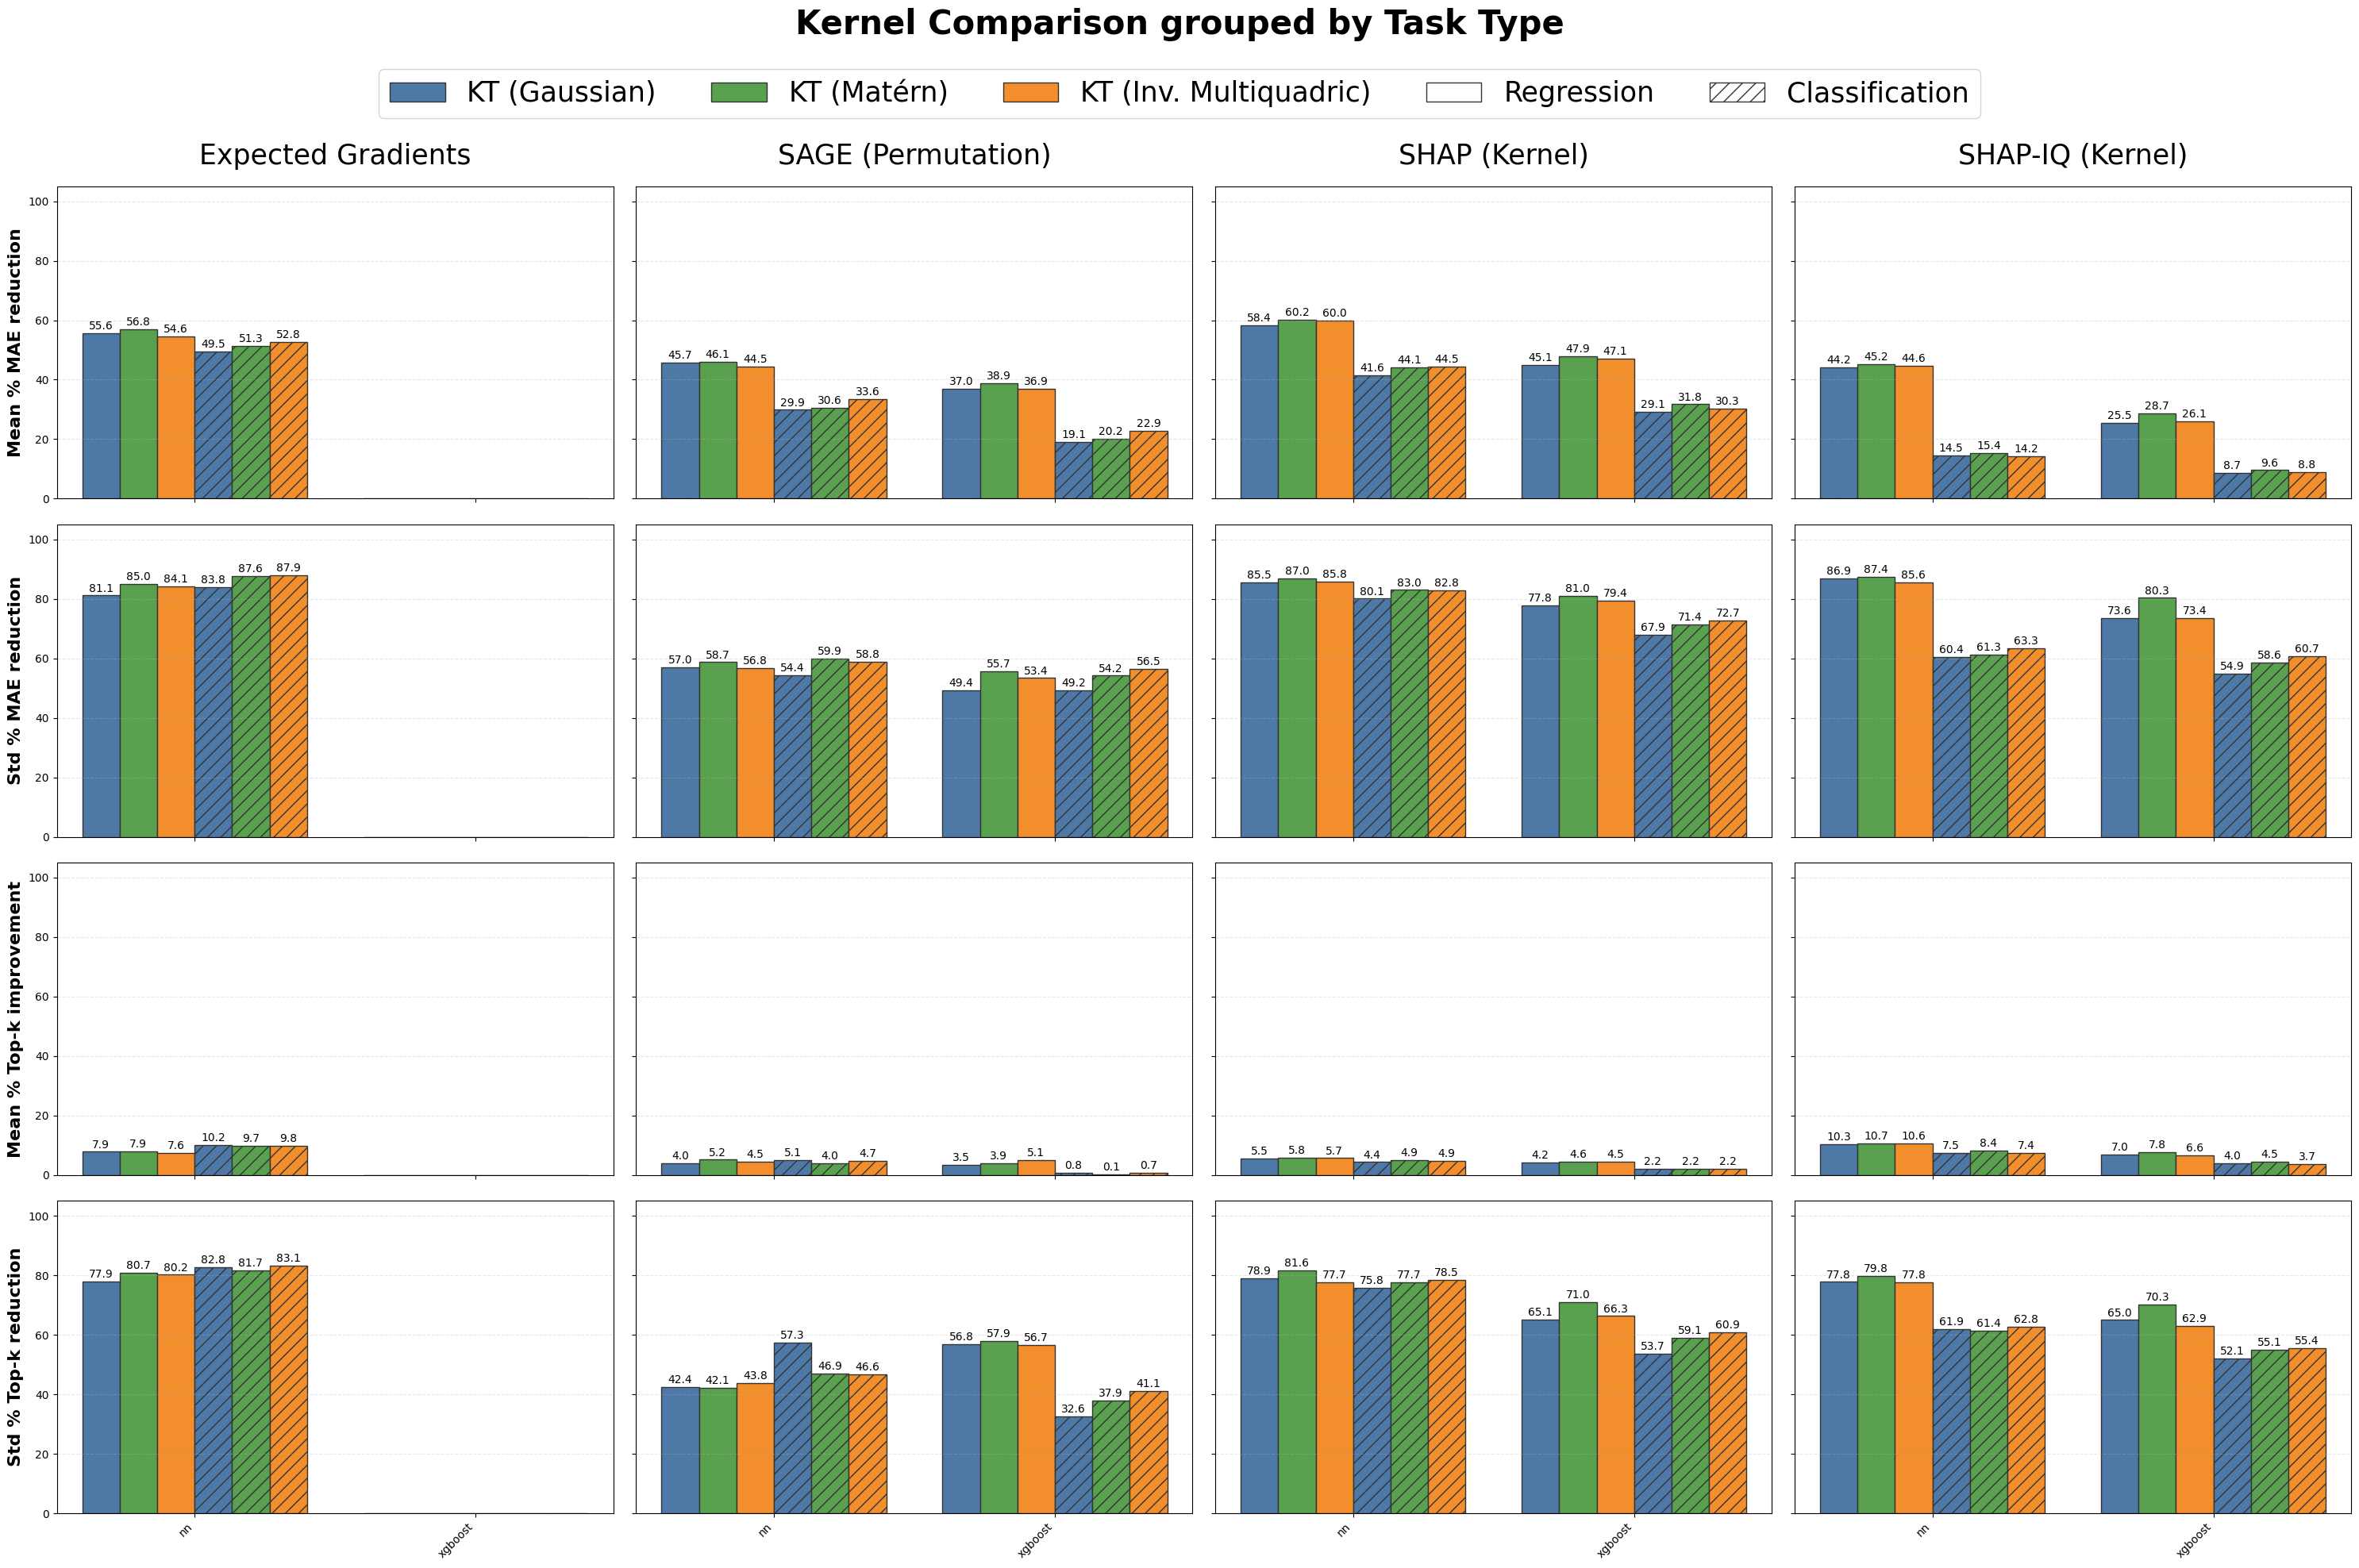

In [11]:
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

output_dir = "./Image15"
os.makedirs(output_dir, exist_ok=True)

metrics_to_analyze = ["mae_mean", "mae_std", "top_k_mean", "top_k_std"]
methods_to_plot = ["kt_gaussian", "kt_matern", "kt_inverse_multiquadric"]
tasks = ["regression", "classification"]

method_colors = {
    "kt_gaussian": "#4E79A7",
    "kt_matern": "#59A14F", 
    "kt_inverse_multiquadric": "#F28E2B",
}

task_hatch = {
    "regression": None,
    "classification": "//",
}

method_labels = {
    "kt_gaussian": "KT (Gaussian)",
    "kt_matern": "KT (Matérn)",
    "kt_inverse_multiquadric": "KT (Inv. Multiquadric)",
}

explainer_labels = {
    "expected_gradients": "Expected Gradients",
    "sage_permutation": "SAGE (Permutation)",
    "shap_kernel": "SHAP (Kernel)",
    "shapiq_kernel": "SHAP-IQ (Kernel)",
}

metric_titles = {
    "mae_mean": "MAE (mean)",
    "mae_std": "MAE (std)",
    "top_k_mean": "Top-k agreement (mean)",
    "top_k_std": "Top-k agreement (std)",
}

metric_ylabels = {
    "mae_mean": "Mean % MAE reduction",
    "mae_std": "Std % MAE reduction",
    "top_k_mean": "Mean % Top-k improvement",
    "top_k_std": "Std % Top-k reduction",
}

edgecolor = "#333333"
zero_tol = 1e-12
label_min_abs = 0.05
all_metric_data = {}

for metric in metrics_to_analyze:
    pct_col = f"{metric}_pct_reduction"
    flip_sign = (metric == "top_k_mean")
    
    dfs = []
    for method in methods_to_plot:
        df_method = (
            results_with_improvements[results_with_improvements["method_total"] == method]
            .groupby(["task", "model_name", "explainer_total"])[[pct_col]]
            .mean()
            .reset_index()
        )
        df_method.rename(columns={pct_col: "mean_improvement"}, inplace=True)
        df_method["method_total"] = method
        dfs.append(df_method)
    
    df_all = pd.concat(dfs, ignore_index=True)
    if flip_sign:
        df_all["mean_improvement"] = -df_all["mean_improvement"]
    
    if df_all["mean_improvement"].abs().max() < 5:
        df_all["mean_improvement"] *= 100
    
    all_metric_data[metric] = df_all

explainers = ["expected_gradients", "sage_permutation", "shap_kernel", "shapiq_kernel"]
models = sorted(all_metric_data["mae_mean"]["model_name"].unique())
Y_MIN, Y_MAX = 0, 105

fig, axes = plt.subplots(4, 4, figsize=(30, 20), sharex=True, sharey=True)

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
})

for row_idx, metric in enumerate(metrics_to_analyze):
    df_all = all_metric_data[metric]
    
    bar_group_width = 0.8
    total_bars = len(methods_to_plot) * len(tasks)
    bar_w = bar_group_width / total_bars
    
    for col_idx, explainer in enumerate(explainers):
        ax = axes[row_idx, col_idx]
        sub = df_all[df_all["explainer_total"] == explainer]
        x = np.arange(len(models))
        
        bar_i = 0
        for task in tasks:
            for method in methods_to_plot:
                task_sub = sub[(sub["method_total"] == method) & (sub["task"] == task)]
                values = []
                for m in models:
                    if m in task_sub["model_name"].values:
                        val = float(task_sub.loc[task_sub["model_name"] == m, "mean_improvement"].values[0])
                        values.append(max(min(val, Y_MAX), Y_MIN))
                    else:
                        values.append(0.0)
                
                offset = (bar_i - (total_bars - 1) / 2) * bar_w
                bars = ax.bar(x + offset, values, width=bar_w, color=method_colors[method],
                              edgecolor=edgecolor, hatch=task_hatch[task], linewidth=1.0)
                
                for b in bars:
                    h = float(b.get_height())
                    if abs(h) < label_min_abs: continue
                    ax.text(b.get_x() + b.get_width() / 2, h + 0.5, f"{h:.1f}", 
                            ha="center", va='bottom', fontsize=10, rotation=0)
                bar_i += 1
        
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=45, ha='right')
        ax.set_ylim(Y_MIN, Y_MAX)
        ax.grid(axis="y", linestyle="--", alpha=0.3)
        
        if row_idx == 0:
            ax.set_title(explainer_labels.get(explainer, explainer), fontsize=25, pad=20)
        if col_idx == 0:
            ax.set_ylabel(metric_ylabels.get(metric, metric), fontsize=16, fontweight='bold')

method_handles = [Patch(facecolor=method_colors[m], edgecolor=edgecolor, label=method_labels[m]) for m in methods_to_plot]
task_handles = [Patch(facecolor="white", edgecolor=edgecolor, hatch=task_hatch[t], label=t.capitalize()) for t in tasks]

fig.legend(handles=method_handles + task_handles, loc='upper center', bbox_to_anchor=(0.5, 0.96),
           ncol=len(methods_to_plot) + len(tasks), frameon=True, fontsize=25)

fig.suptitle("Kernel Comparison grouped by Task Type", fontsize=30, y=0.99, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(f"{output_dir}/mae_topk_task_grouped.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Figure 16

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import pandas as pd
import os

os.makedirs("Image16", exist_ok=True)
results_aggregated = pd.read_csv("../package_metadata/results_aggregation.csv")

PRED_METHOD = "kt_predictions"
BASE_METHOD = "kt_gaussian"

models = results_aggregated["model_name"].unique()
explainers = results_aggregated["explainer_total"].unique()
tasks = results_aggregated["task"].unique()

flags = [
    ("predictions_outperform_kt_mae", "MAE mean"),
    ("predictions_outperform_kt_topk", "Top-K mean"),
    ("predictions_outperform_kt_std_mae", "MAE std"),
    ("predictions_outperform_kt_std_topk", "Top-K std"),
]

for task in tasks:
    for model in models:
        if task == "classification":
            y_metric = "f1_ann" if model == "nn" else "f1_xgboost"
        else:
            y_metric = "improvement_ann_percent" if model == "nn" else "improvement_xgboost_percent"
        
        for explainer in explainers:
            if y_metric not in results_aggregated.columns:
                continue

            res_pred = results_aggregated[
                (results_aggregated["method_total"] == PRED_METHOD) &
                (results_aggregated["explainer_total"] == explainer) &
                (results_aggregated["model_name"] == model) &
                (results_aggregated["task"] == task)
            ].copy()

            res_base = results_aggregated[
                (results_aggregated["method_total"] == BASE_METHOD) &
                (results_aggregated["explainer_total"] == explainer) &
                (results_aggregated["model_name"] == model) &
                (results_aggregated["task"] == task)
            ].copy()

            if res_pred.empty or res_base.empty:
                continue

            merged = pd.merge(
                res_pred, res_base,
                on=["size", "compression_coefficient", "model_name", "dataset_name", "task", "explainer_total", y_metric],
                suffixes=("_pred", "_base")
            )
            
            if merged.empty:
                continue

            merged[y_metric] = pd.to_numeric(merged[y_metric], errors='coerce')
            merged = merged.dropna(subset=[y_metric])

            merged['predictions_outperform_kt_mae'] = merged['mae_mean_pred'] < merged['mae_mean_base']
            merged['predictions_outperform_kt_topk'] = merged['top_k_mean_pred'] > merged['top_k_mean_base']
            merged['predictions_outperform_kt_std_mae'] = merged['mae_std_pred'] < merged['mae_std_base']
            merged['predictions_outperform_kt_std_topk'] = merged['top_k_std_pred'] > merged['top_k_std_base']

            compression_values = sorted(merged["compression_coefficient"].unique())
            cmap = plt.cm.Blues
            norm = mcolors.Normalize(vmin=min(compression_values), vmax=max(compression_values))

            fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True, constrained_layout=True)

            for ax, (flag, title) in zip(axes, flags):
                data_f = merged.loc[merged[flag] == False, y_metric].values.astype(float)
                data_t = merged.loc[merged[flag] == True, y_metric].values.astype(float)
                
                plot_data = [data_f, data_t]
                
                ax.boxplot(
                    plot_data, 
                    labels=["False", "True"], 
                    showfliers=False, 
                    widths=0.75,
                    boxprops=dict(linewidth=1.5), 
                    medianprops=dict(linewidth=2, color="black")
                )

                for i, flag_val in enumerate([False, True], start=1):
                    subset = merged[merged[flag] == flag_val]
                    for j, cc in enumerate(compression_values):
                        pts = subset[subset["compression_coefficient"] == cc][y_metric].values.astype(float)
                        if len(pts) == 0: continue
                        
                        shift = (j - len(compression_values)/2) * 0.08
                        x = np.full(len(pts), i + shift) + np.random.normal(0, 0.01, size=len(pts))
                        ax.scatter(x, pts, s=50, alpha=0.8, color=cmap(0.4 + 0.6 * norm(cc)), 
                                   edgecolors='black', linewidths=0.4, zorder=3)

                ax.set_title(title, fontweight='bold')
                ax.set_xlabel("Preds outperform Gaussian")
                ax.grid(axis='y', linestyle='--', alpha=0.3)

            axes[0].set_ylabel(y_metric.replace('_', ' ').upper(), fontweight='bold')
            
            sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
            cbar = fig.colorbar(sm, ax=axes, location="right", shrink=0.7)
            cbar.set_label("Compression Coefficient (CC)")

            fig.suptitle(f"Analysis: {model.upper()} | Explainer: {explainer} | Task: {task.capitalize()}\nMetric: {y_metric}", 
                         fontsize=14, fontweight='bold')

            filename = f"Image16/comparison_{task}_{model}_{explainer}.pdf"
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            plt.close(fig)

print("Process completed.")

/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_35519/3212137368.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_35519/3212137368.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_35519/3212137368.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_35519/3212137368.py:81: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; 

Process completed.


# Image 17

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import pandas as pd
import os

os.makedirs("Image17", exist_ok=True)
results_aggregated = pd.read_csv("../package_metadata/results_aggregation.csv")

PRED_METHOD = "kt_predictions"
BASE_METHOD = "kt_gaussian"
Y_METRIC = 'n_classes'
COLOR_METRIC = 'compression_coefficient'

models = results_aggregated["model_name"].unique()
explainers = results_aggregated["explainer_total"].unique()

flags = [
    ("predictions_outperform_kt_mae", "MAE mean"),
    ("predictions_outperform_kt_topk", "Top-K mean"),
    ("predictions_outperform_kt_std_mae", "MAE std"),
    ("predictions_outperform_kt_std_topk", "Top-K std"),
]

for model in models:
    for explainer in explainers:
        
        res_pred = results_aggregated[
            (results_aggregated["method_total"] == PRED_METHOD) &
            (results_aggregated["model_name"] == model) &
            (results_aggregated["explainer_total"] == explainer) &
            (results_aggregated["task"] == "classification")
        ].copy()

        res_base = results_aggregated[
            (results_aggregated["method_total"] == BASE_METHOD) &
            (results_aggregated["model_name"] == model) &
            (results_aggregated["explainer_total"] == explainer) &
            (results_aggregated["task"] == "classification")
        ].copy()

        if res_pred.empty or res_base.empty:
            continue

        merged = pd.merge(
            res_pred, res_base,
            on=["size", "compression_coefficient", "model_name", "dataset_name", "n_classes", "task", "explainer_total"],
            suffixes=("_pred", "_base")
        )

        if merged.empty:
            continue

        merged[Y_METRIC] = pd.to_numeric(merged[Y_METRIC], errors='coerce')
        merged = merged.dropna(subset=[Y_METRIC])
        
        merged['predictions_outperform_kt_mae'] = merged['mae_mean_pred'] < merged['mae_mean_base']
        merged['predictions_outperform_kt_topk'] = merged['top_k_mean_pred'] > merged['top_k_mean_base']
        merged['predictions_outperform_kt_std_mae'] = merged['mae_std_pred'] < merged['mae_std_base']
        merged['predictions_outperform_kt_std_topk'] = merged['top_k_std_pred'] > merged['top_k_std_base']

        compression_values = sorted(merged[COLOR_METRIC].unique())
        cmap = plt.cm.Blues
        norm = mcolors.Normalize(vmin=min(compression_values), vmax=max(compression_values))

        fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True, constrained_layout=True)

        for ax, (flag, title) in zip(axes, flags):
            data_f = merged.loc[merged[flag] == False, Y_METRIC].values.astype(float)
            data_t = merged.loc[merged[flag] == True, Y_METRIC].values.astype(float)
            
            ax.boxplot(
                [data_f, data_t], 
                labels=["False", "True"], 
                showfliers=False, 
                widths=0.75,
                boxprops=dict(linewidth=1.5), 
                medianprops=dict(linewidth=2, color="black")
            )

            for i, flag_val in enumerate([False, True], start=1):
                subset = merged[merged[flag] == flag_val]
                for j, cc in enumerate(compression_values):
                    pts = subset[subset[COLOR_METRIC] == cc][Y_METRIC].values.astype(float)
                    if len(pts) == 0: continue
                    
                    shift = (j - len(compression_values)/2) * 0.08
                    x = np.full(len(pts), i + shift) + np.random.normal(0, 0.01, size=len(pts))
                    ax.scatter(x, pts, s=50, alpha=0.8, color=cmap(0.4 + 0.6 * norm(cc)), 
                               edgecolors='black', linewidths=0.4, zorder=3)

            ax.set_title(title, fontweight='bold')
            ax.set_xlabel("Preds outperform Gaussian")
            ax.grid(axis='y', linestyle='--', alpha=0.3)

        axes[0].set_ylabel("Number of Classes", fontweight='bold')
        
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
        cbar = fig.colorbar(sm, ax=axes, location="right", shrink=0.7)
        cbar.set_label("Compression Coefficient (CC)")

        fig.suptitle(f"Model: {model.upper()} | Explainer: {explainer} | Task: Classification\nAnalysis by n_classes", 
                     fontsize=14, fontweight='bold')

        filename = f"Image17/classes_analysis_{model}_{explainer}.pdf"
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.close(fig)

print("Process completed. Check Image17 folder.")

/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_35519/3229907052.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_35519/3229907052.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_35519/3229907052.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_35519/3229907052.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; 

Process completed. Check Image17 folder.


# Image 18

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import pandas as pd
import os

os.makedirs("Image18", exist_ok=True)
results_aggregated = pd.read_csv("../package_metadata/results_aggregation.csv")

PRED_METHOD = "kt_predictions"
BASE_METHOD = "kt_gaussian"
Y_METRIC = 'n_features_after_preprocessing'
COLOR_METRIC = 'compression_coefficient'

models = results_aggregated["model_name"].unique()
explainers = results_aggregated["explainer_total"].unique()

flags = [
    ("predictions_outperform_kt_mae", "MAE mean"),
    ("predictions_outperform_kt_topk", "Top-K mean"),
    ("predictions_outperform_kt_std_mae", "MAE std"),
    ("predictions_outperform_kt_std_topk", "Top-K std"),
]

for model in models:
    for explainer in explainers:
        
        res_pred = results_aggregated[
            (results_aggregated["method_total"] == PRED_METHOD) &
            (results_aggregated["model_name"] == model) &
            (results_aggregated["explainer_total"] == explainer) &
            (results_aggregated["task"] == "classification")
        ].copy()

        res_base = results_aggregated[
            (results_aggregated["method_total"] == BASE_METHOD) &
            (results_aggregated["model_name"] == model) &
            (results_aggregated["explainer_total"] == explainer) &
            (results_aggregated["task"] == "classification")
        ].copy()

        if res_pred.empty or res_base.empty:
            continue

        merged = pd.merge(
            res_pred, res_base,
            on=["size", "compression_coefficient", "model_name", "dataset_name", Y_METRIC, "task", "explainer_total"],
            suffixes=("_pred", "_base")
        )

        if merged.empty:
            continue

        merged[Y_METRIC] = pd.to_numeric(merged[Y_METRIC], errors='coerce')
        merged = merged.dropna(subset=[Y_METRIC])
        
        merged['predictions_outperform_kt_mae'] = merged['mae_mean_pred'] < merged['mae_mean_base']
        merged['predictions_outperform_kt_topk'] = merged['top_k_mean_pred'] > merged['top_k_mean_base']
        merged['predictions_outperform_kt_std_mae'] = merged['mae_std_pred'] < merged['mae_std_base']
        merged['predictions_outperform_kt_std_topk'] = merged['top_k_std_pred'] > merged['top_k_std_base']

        compression_values = sorted(merged[COLOR_METRIC].unique())
        cmap = plt.cm.Blues
        norm = mcolors.Normalize(vmin=min(compression_values), vmax=max(compression_values))

        fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True, constrained_layout=True)

        for ax, (flag, title) in zip(axes, flags):
            data_f = merged.loc[merged[flag] == False, Y_METRIC].values.astype(float)
            data_t = merged.loc[merged[flag] == True, Y_METRIC].values.astype(float)
            
            ax.boxplot(
                [data_f, data_t], 
                labels=["False", "True"], 
                showfliers=False, 
                widths=0.75,
                boxprops=dict(linewidth=1.5), 
                medianprops=dict(linewidth=2, color="black")
            )

            for i, flag_val in enumerate([False, True], start=1):
                subset = merged[merged[flag] == flag_val]
                for j, cc in enumerate(compression_values):
                    pts = subset[subset[COLOR_METRIC] == cc][Y_METRIC].values.astype(float)
                    if len(pts) == 0: continue
                    
                    shift = (j - len(compression_values)/2) * 0.08
                    x = np.full(len(pts), i + shift) + np.random.normal(0, 0.01, size=len(pts))
                    ax.scatter(x, pts, s=50, alpha=0.8, color=cmap(0.4 + 0.6 * norm(cc)), 
                               edgecolors='black', linewidths=0.4, zorder=3)

            ax.set_title(title, fontweight='bold')
            ax.set_xlabel("Preds outperform Gaussian")
            ax.grid(axis='y', linestyle='--', alpha=0.3)

        axes[0].set_ylabel("Number of Features", fontweight='bold')
        
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
        cbar = fig.colorbar(sm, ax=axes, location="right", shrink=0.7)
        cbar.set_label("Compression Coefficient (CC)")

        fig.suptitle(f"Model: {model.upper()} | Explainer: {explainer} | Task: Classification\nAnalysis by n_features", 
                     fontsize=14, fontweight='bold')

        filename = f"Image18/features_analysis_{model}_{explainer}.pdf"
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.close(fig)


/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_35519/3925082509.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_35519/3925082509.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_35519/3925082509.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_35519/3925082509.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; 

# Image 19

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import pandas as pd
import os

os.makedirs("Image19", exist_ok=True)
results_aggregated = pd.read_csv("../package_metadata/results_aggregation.csv")

PRED_METHOD = "kt_stratified"
BASE_METHOD = "kt_gaussian"
Y_METRIC = 'n_features_after_preprocessing'
COLOR_METRIC = 'compression_coefficient'

models = results_aggregated["model_name"].unique()
explainers = results_aggregated["explainer_total"].unique()

flags = [
    ("predictions_outperform_kt_mae", "MAE mean"),
    ("predictions_outperform_kt_topk", "Top-K mean"),
    ("predictions_outperform_kt_std_mae", "MAE std"),
    ("predictions_outperform_kt_std_topk", "Top-K std"),
]

for model in models:
    for explainer in explainers:
        
        res_pred = results_aggregated[
            (results_aggregated["method_total"] == PRED_METHOD) &
            (results_aggregated["model_name"] == model) &
            (results_aggregated["explainer_total"] == explainer) &
            (results_aggregated["task"] == "classification")
        ].copy()

        res_base = results_aggregated[
            (results_aggregated["method_total"] == BASE_METHOD) &
            (results_aggregated["model_name"] == model) &
            (results_aggregated["explainer_total"] == explainer) &
            (results_aggregated["task"] == "classification")
        ].copy()

        if res_pred.empty or res_base.empty:
            continue

        merged = pd.merge(
            res_pred, res_base,
            on=["size", "compression_coefficient", "model_name", "dataset_name", Y_METRIC, "task", "explainer_total"],
            suffixes=("_pred", "_base")
        )

        if merged.empty:
            continue

        merged[Y_METRIC] = pd.to_numeric(merged[Y_METRIC], errors='coerce')
        merged = merged.dropna(subset=[Y_METRIC])
        
        merged['predictions_outperform_kt_mae'] = merged['mae_mean_pred'] < merged['mae_mean_base']
        merged['predictions_outperform_kt_topk'] = merged['top_k_mean_pred'] > merged['top_k_mean_base']
        merged['predictions_outperform_kt_std_mae'] = merged['mae_std_pred'] < merged['mae_std_base']
        merged['predictions_outperform_kt_std_topk'] = merged['top_k_std_pred'] > merged['top_k_std_base']

        compression_values = sorted(merged[COLOR_METRIC].unique())
        cmap = plt.cm.Blues
        norm = mcolors.Normalize(vmin=min(compression_values), vmax=max(compression_values))

        fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True, constrained_layout=True)

        for ax, (flag, title) in zip(axes, flags):
            data_f = merged.loc[merged[flag] == False, Y_METRIC].values.astype(float)
            data_t = merged.loc[merged[flag] == True, Y_METRIC].values.astype(float)
            
            ax.boxplot(
                [data_f, data_t], 
                labels=["False", "True"], 
                showfliers=False, 
                widths=0.75,
                boxprops=dict(linewidth=1.5), 
                medianprops=dict(linewidth=2, color="black")
            )

            for i, flag_val in enumerate([False, True], start=1):
                subset = merged[merged[flag] == flag_val]
                for j, cc in enumerate(compression_values):
                    pts = subset[subset[COLOR_METRIC] == cc][Y_METRIC].values.astype(float)
                    if len(pts) == 0: continue
                    
                    shift = (j - len(compression_values)/2) * 0.08
                    x = np.full(len(pts), i + shift) + np.random.normal(0, 0.01, size=len(pts))
                    ax.scatter(x, pts, s=50, alpha=0.8, color=cmap(0.4 + 0.6 * norm(cc)), 
                               edgecolors='black', linewidths=0.4, zorder=3)

            ax.set_title(title, fontweight='bold')
            ax.set_xlabel("stratified outperform Gaussian")
            ax.grid(axis='y', linestyle='--', alpha=0.3)

        axes[0].set_ylabel("Number of Features", fontweight='bold')
        
        sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
        cbar = fig.colorbar(sm, ax=axes, location="right", shrink=0.7)
        cbar.set_label("Compression Coefficient (CC)")

        fig.suptitle(f"Model: {model.upper()} | Explainer: {explainer} | Task: Classification\nAnalysis by n_features", 
                     fontsize=14, fontweight='bold')

        filename = f"Image19/features_analysis_{model}_{explainer}.pdf"
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.close(fig)


/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_35519/1330053692.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_35519/1330053692.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_35519/1330053692.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_35519/1330053692.py:72: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; 

# Image 20

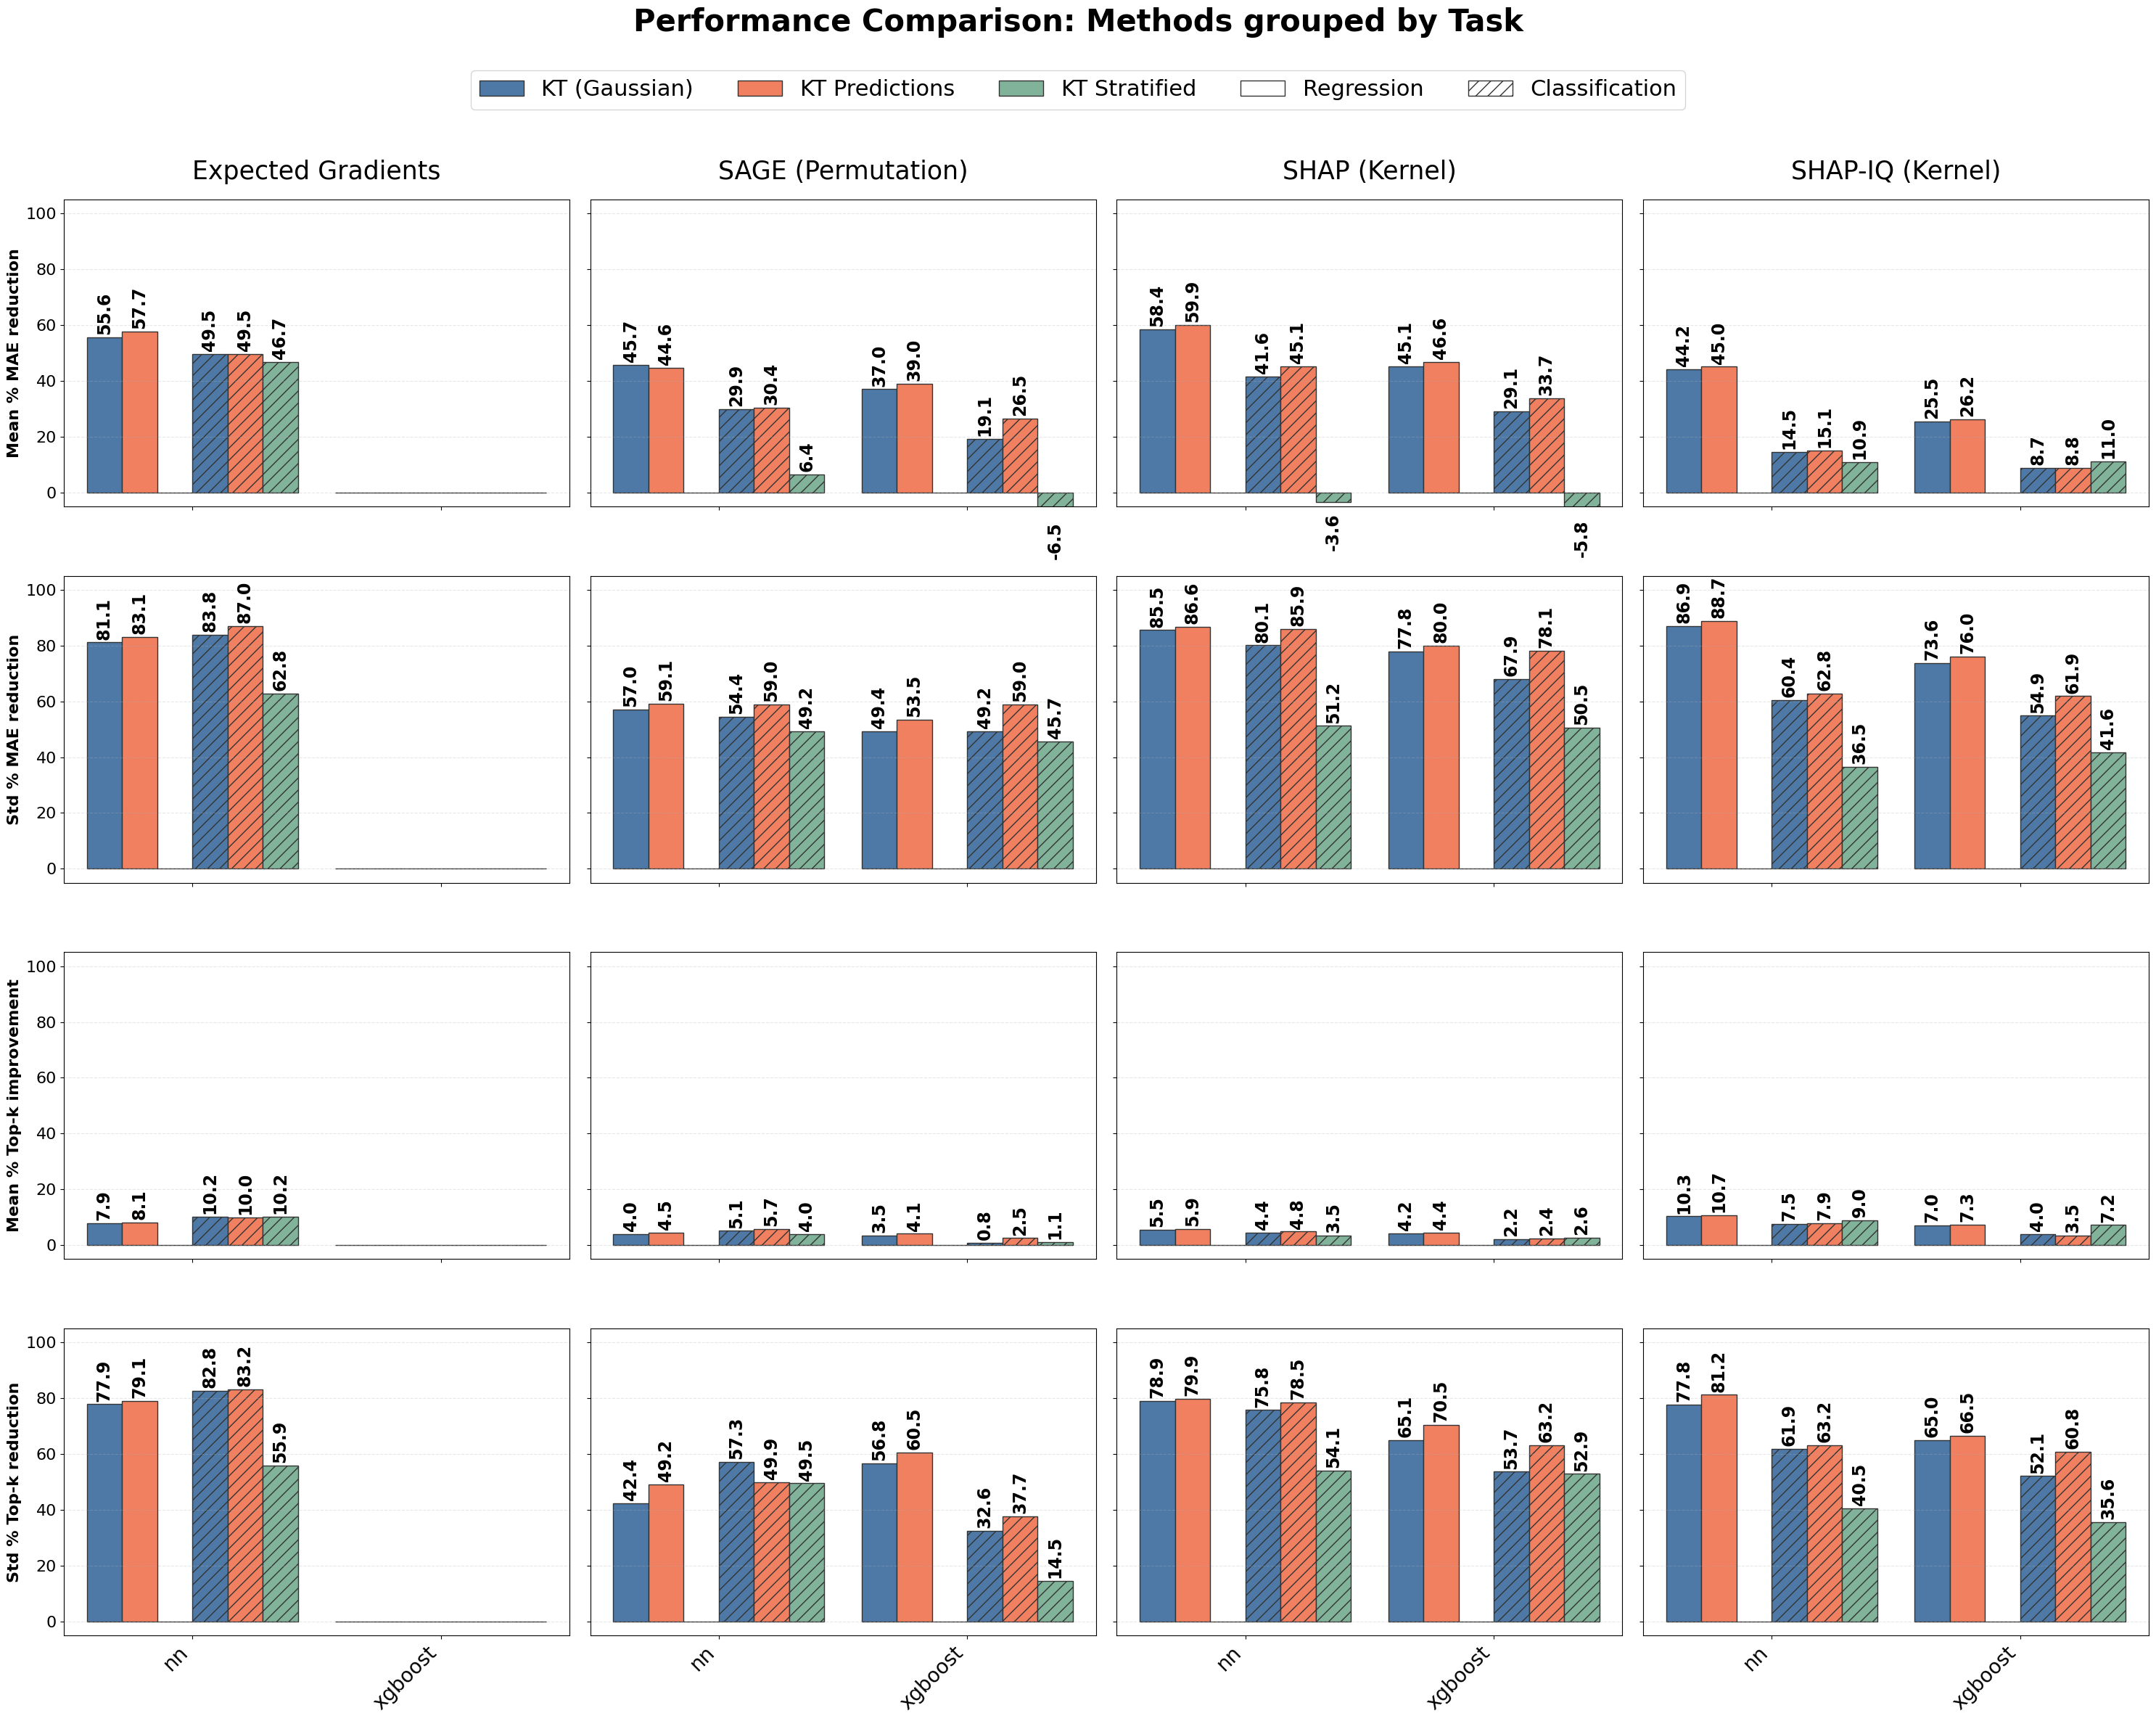

In [5]:
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
from matplotlib.patches import Patch

output_dir = "Image20"
os.makedirs(output_dir, exist_ok=True)

metrics_to_analyze = ["mae_mean", "mae_std", "top_k_mean", "top_k_std"]
methods_to_plot = ["kt_gaussian", "kt_predictions", "kt_stratified"]
tasks = ["regression", "classification"]

method_colors = {
    "kt_gaussian": "#4E79A7",
    "kt_stratified": "#81b29a",
    "kt_predictions": "#f08060"
}

task_hatch = {
    "regression": None,
    "classification": "//",
}

method_labels = {
    "kt_gaussian": "KT (Gaussian)",
    "kt_stratified": "KT Stratified",
    "kt_predictions": "KT Predictions"
}

explainer_labels = {
    "expected_gradients": "Expected Gradients",
    "sage_permutation": "SAGE (Permutation)",
    "shap_kernel": "SHAP (Kernel)",
    "shapiq_kernel": "SHAP-IQ (Kernel)",
}

metric_ylabels = {
    "mae_mean": "Mean % MAE reduction",
    "mae_std": "Std % MAE reduction",
    "top_k_mean": "Mean % Top-k improvement",
    "top_k_std": "Std % Top-k reduction",
}

edgecolor = "#333333"
label_min_abs = 0.5
all_metric_data = {}

for metric in metrics_to_analyze:
    pct_col = f"{metric}_pct_reduction"
    flip_sign = (metric == "top_k_mean")
    
    dfs = []
    for method in methods_to_plot:
        temp_df = results_with_improvements[results_with_improvements["method_total"] == method]
        if temp_df.empty: continue
        
        df_method = (
            temp_df.groupby(["task", "model_name", "explainer_total"])[[pct_col]]
            .mean()
            .reset_index()
        )
        df_method.rename(columns={pct_col: "mean_improvement"}, inplace=True)
        df_method["method_total"] = method
        dfs.append(df_method)
    
    if not dfs:
        continue
        
    df_all = pd.concat(dfs, ignore_index=True)
    
    if flip_sign:
        df_all["mean_improvement"] = -df_all["mean_improvement"]
    
    if df_all["mean_improvement"].abs().max() < 5:
        df_all["mean_improvement"] *= 100
    
    all_metric_data[metric] = df_all

explainers = ["expected_gradients", "sage_permutation", "shap_kernel", "shapiq_kernel"]

if "mae_mean" in all_metric_data:
    models = sorted(all_metric_data["mae_mean"]["model_name"].unique())
else:
    models = []

Y_MIN, Y_MAX = -5, 105

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 16,
})

fig, axes = plt.subplots(4, 4, figsize=(30, 24), sharex=True, sharey=True)

for row_idx, metric in enumerate(metrics_to_analyze):
    if metric not in all_metric_data:
        continue

    df_all = all_metric_data[metric]
    
    bar_group_width = 0.85
    total_bars = len(methods_to_plot) * len(tasks)
    bar_w = bar_group_width / total_bars
    
    for col_idx, explainer in enumerate(explainers):
        ax = axes[row_idx, col_idx]
        sub = df_all[df_all["explainer_total"] == explainer]
        x = np.arange(len(models))
        
        bar_i = 0
        for task in tasks:
            for method in methods_to_plot:
                task_sub = sub[(sub["method_total"] == method) & (sub["task"] == task)]
                
                values = []
                for m in models:
                    if m in task_sub["model_name"].values:
                        val = float(task_sub.loc[task_sub["model_name"] == m, "mean_improvement"].values[0])
                        values.append(val)
                    else:
                        values.append(0.0)
                
                offset = (bar_i - (total_bars - 1) / 2) * bar_w
                
                bars = ax.bar(x + offset, values, width=bar_w, color=method_colors[method],
                              edgecolor=edgecolor, hatch=task_hatch[task], linewidth=1.0)
                
                for b in bars:
                    h = float(b.get_height())
                    if abs(h) < label_min_abs: continue
                    
                    text_y = h + 1 if h >= 0 else h - 4
                    va_align = 'bottom' if h >= 0 else 'top'
                    
                    ax.text(b.get_x() + b.get_width() / 2, text_y, f"{h:.1f}", 
                            ha="center", va=va_align, fontsize=17, rotation=90, fontweight='bold')
                bar_i += 1
        
        if row_idx == 3:
            ax.set_xticks(x)
            ax.set_xticklabels(models, rotation=45, ha='right', fontsize=20)
        
        ax.set_ylim(Y_MIN, Y_MAX)
        ax.grid(axis="y", linestyle="--", alpha=0.3)
        
        if row_idx == 0:
            ax.set_title(explainer_labels.get(explainer, explainer), fontsize=25, pad=20)
        if col_idx == 0:
            ax.set_ylabel(metric_ylabels.get(metric, metric), fontsize=16, fontweight='bold')

method_handles = [Patch(facecolor=method_colors[m], edgecolor=edgecolor, label=method_labels[m]) for m in methods_to_plot]
task_handles = [Patch(facecolor="white", edgecolor=edgecolor, hatch=task_hatch[t], label=t.capitalize()) for t in tasks]

fig.legend(handles=method_handles + task_handles, loc='upper center', bbox_to_anchor=(0.5, 0.96),
           ncol=len(methods_to_plot) + len(tasks), frameon=True, fontsize=22)

fig.suptitle("Performance Comparison: Methods grouped by Task", fontsize=30, y=0.99, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(f"{output_dir}/custom_methods_comparison_4x4.pdf", dpi=300, bbox_inches='tight')
plt.show()

# Image 21

/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_35519/2470440246.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


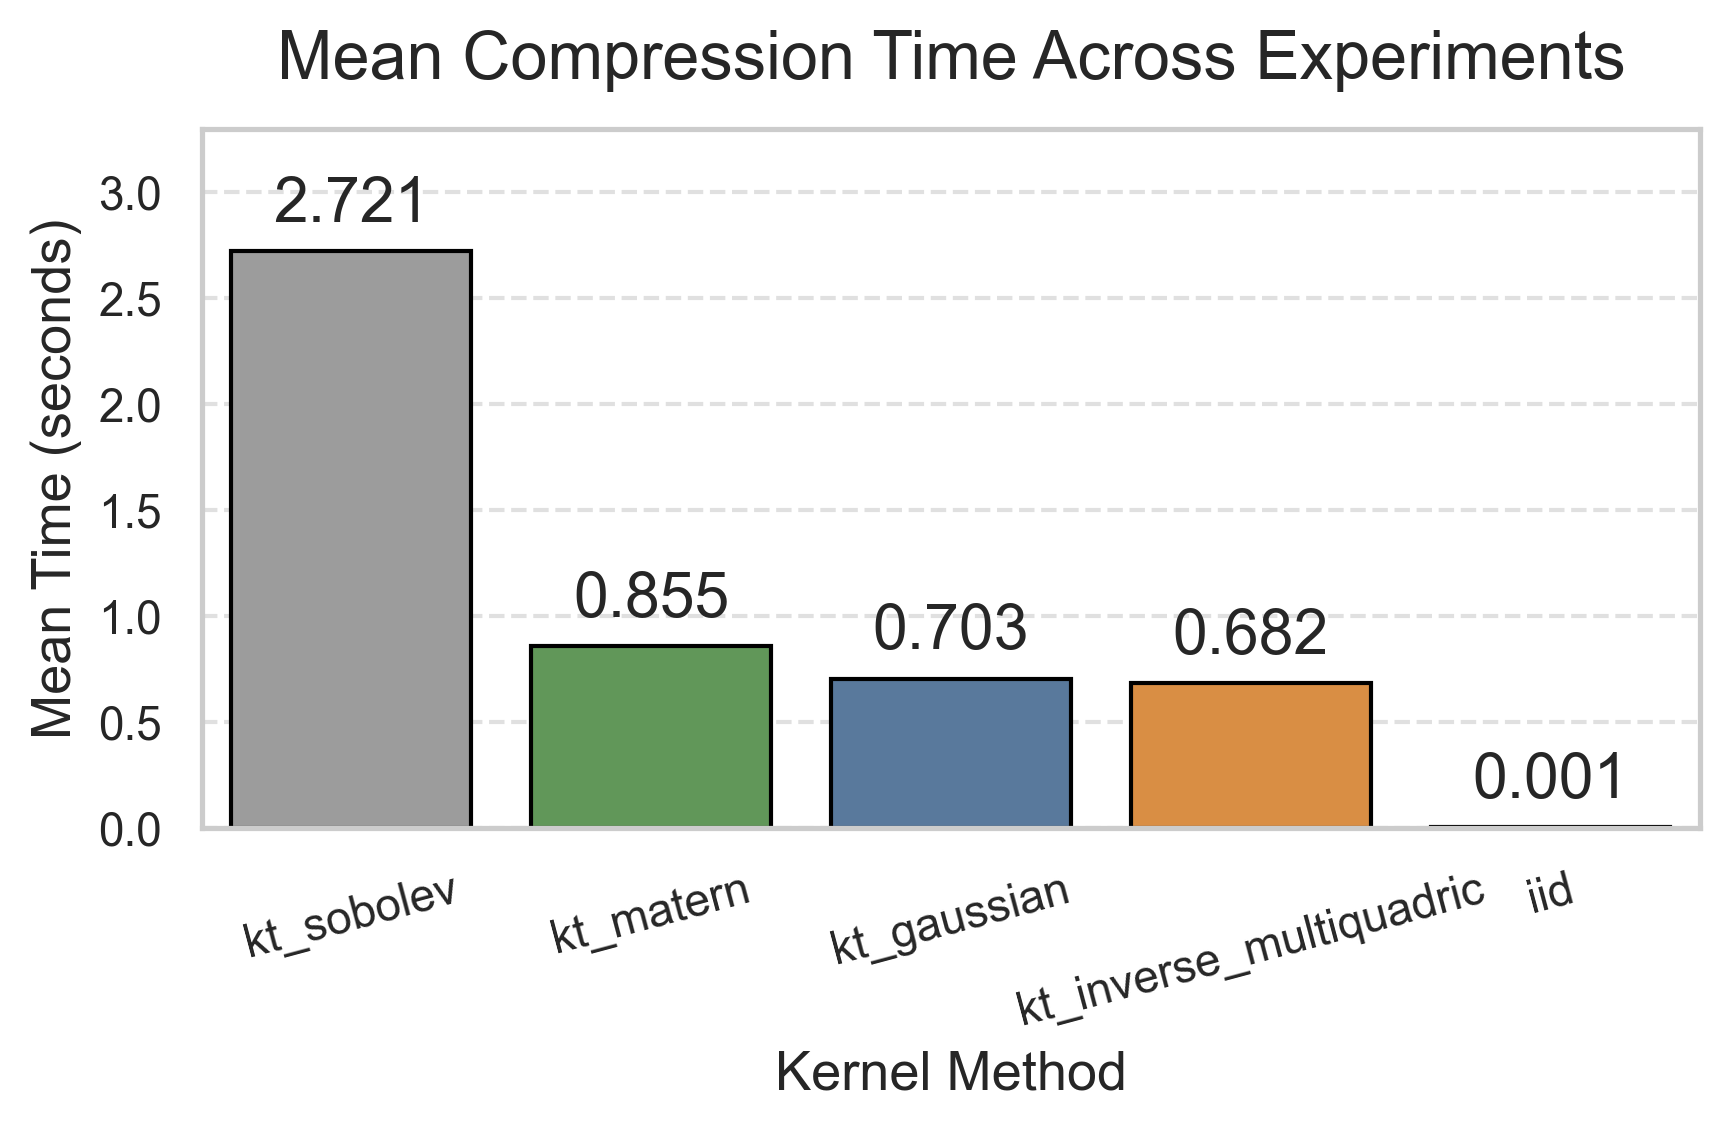

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Data ---
results_aggregated = pd.read_csv("../package_metadata/results_aggregation.csv")

all_methods = [
    'kt_gaussian',
    'kt_matern',
    'kt_inverse_multiquadric',
    'kt_sobolev',
    'iid'
]

results_aggregated = results_aggregated[
    results_aggregated['method_total'].isin(all_methods)
]

results_aggregated = results_aggregated[
    (results_aggregated['model_name'] == 'nn') &
    (results_aggregated['explainer_total'].isin(
        ['expected_gradients', 'sage_permutation']
    ))
]

plot_data = (
    results_aggregated
    .groupby('method_total', as_index=False)['compression_time_mean']
    .mean()
    .sort_values(by='compression_time_mean', ascending=False)
)

# --- Style ---
sns.set_theme(
    style="whitegrid",
    font_scale=1.2
)

method_colors = {
    "kt_gaussian": "#4E79A7",
    "kt_matern": "#59A14F",
    "kt_inverse_multiquadric": "#F28E2B",
    "kt_sobolev": "#9C9C9C",
    "iid": "#1F51FF",
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

sns.barplot(
    data=plot_data,
    x="method_total",
    y="compression_time_mean",
    palette=method_colors,
    edgecolor="black",
    linewidth=1,
    ax=ax
)

# --- Labels ---
ax.set_title(
    "Mean Compression Time Across Experiments",
    fontsize=16,
    pad=12
)
ax.set_xlabel("Kernel Method", fontsize=13)
ax.set_ylabel("Mean Time (seconds)", fontsize=13)

ax.tick_params(axis="x", rotation=15)
ax.tick_params(axis="both", labelsize=11)

# --- Grid ---
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.grid(axis="x", visible=False)

ax.set_ylim(0, 3.3)

# --- Annotations ---
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=4,
        fontsize=15
    )

# --- Layout & Save ---
plt.tight_layout()
plt.savefig(
    "Image21/compression_time_kernels_compared.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)


# Image21 - compression time - baselines comparison

/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_2008/2064502934.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


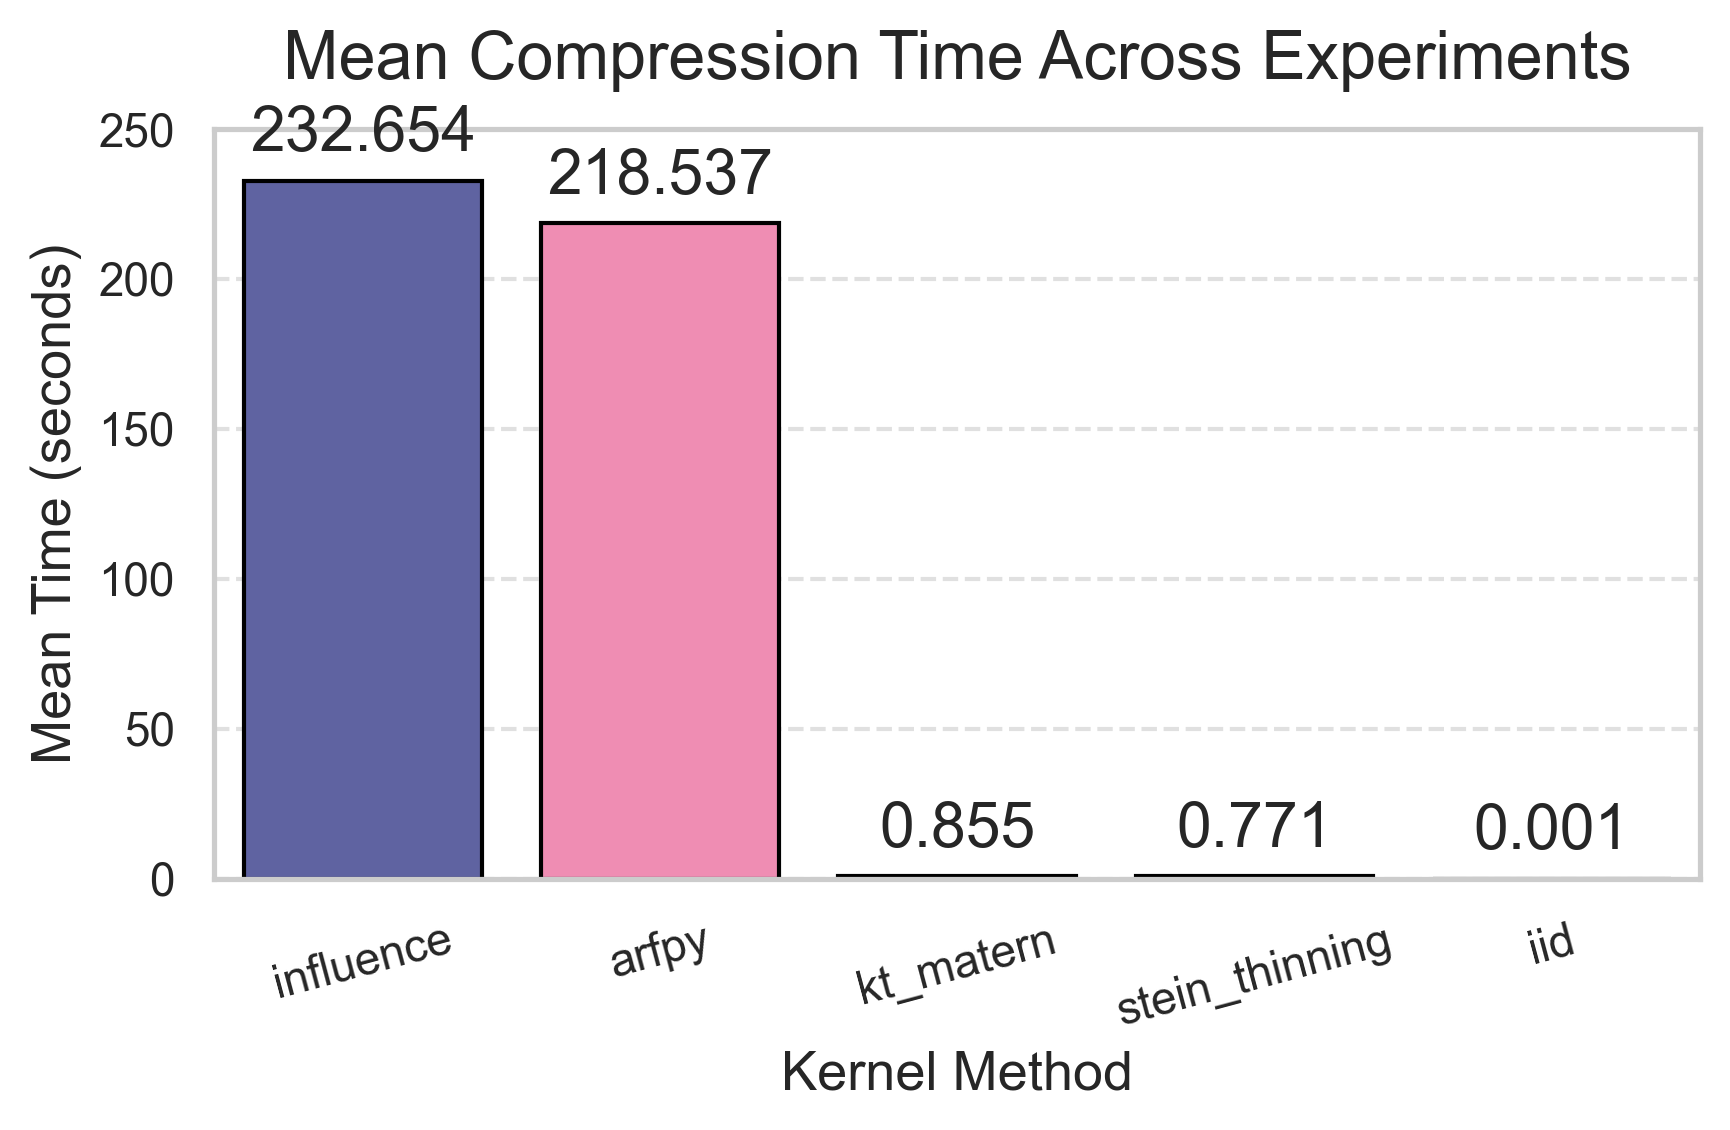

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Data ---
results_aggregated = pd.read_csv("../package_metadata/results_aggregation.csv")

all_methods = [
    'kt_matern',
    'arfpy',
    'stein_thinning',
    'influence',
    'iid'
]

results_aggregated = results_aggregated[
    results_aggregated['method_total'].isin(all_methods)
]

results_aggregated = results_aggregated[
    (results_aggregated['model_name'] == 'nn') &
    (results_aggregated['explainer_total'].isin(
        ['expected_gradients', 'sage_permutation']
    ))
]

plot_data = (
    results_aggregated
    .groupby('method_total', as_index=False)['compression_time_mean']
    .mean()
    .sort_values(by='compression_time_mean', ascending=False)
)

# --- Style ---
sns.set_theme(
    style="whitegrid",
    font_scale=1.2
)

method_colors = {
    "kt_matern": "#59A14F",
    "arfpy": "#FF7DB0",
    "stein_thinning": "#B8DB80",
    "influence": "#5459AC",
    "iid": "#1F51FF",
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

sns.barplot(
    data=plot_data,
    x="method_total",
    y="compression_time_mean",
    palette=method_colors,
    edgecolor="black",
    linewidth=1,
    ax=ax
)

# --- Labels ---
ax.set_title(
    "Mean Compression Time Across Experiments",
    fontsize=16,
    pad=12
)
ax.set_xlabel("Kernel Method", fontsize=13)
ax.set_ylabel("Mean Time (seconds)", fontsize=13)

ax.tick_params(axis="x", rotation=15)
ax.tick_params(axis="both", labelsize=11)

# --- Grid ---
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.grid(axis="x", visible=False)

ax.set_ylim(0, 250)

# --- Annotations ---
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=4,
        fontsize=15
    )

# --- Layout & Save ---
plt.tight_layout()
plt.savefig(
    "Image21/compression_time_baselines_compared.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)


# Image21 - compression time - custom meth comparison

/var/folders/zl/cns9wcts6cd33lrhp33f3rsc0000gn/T/ipykernel_94301/3657913675.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


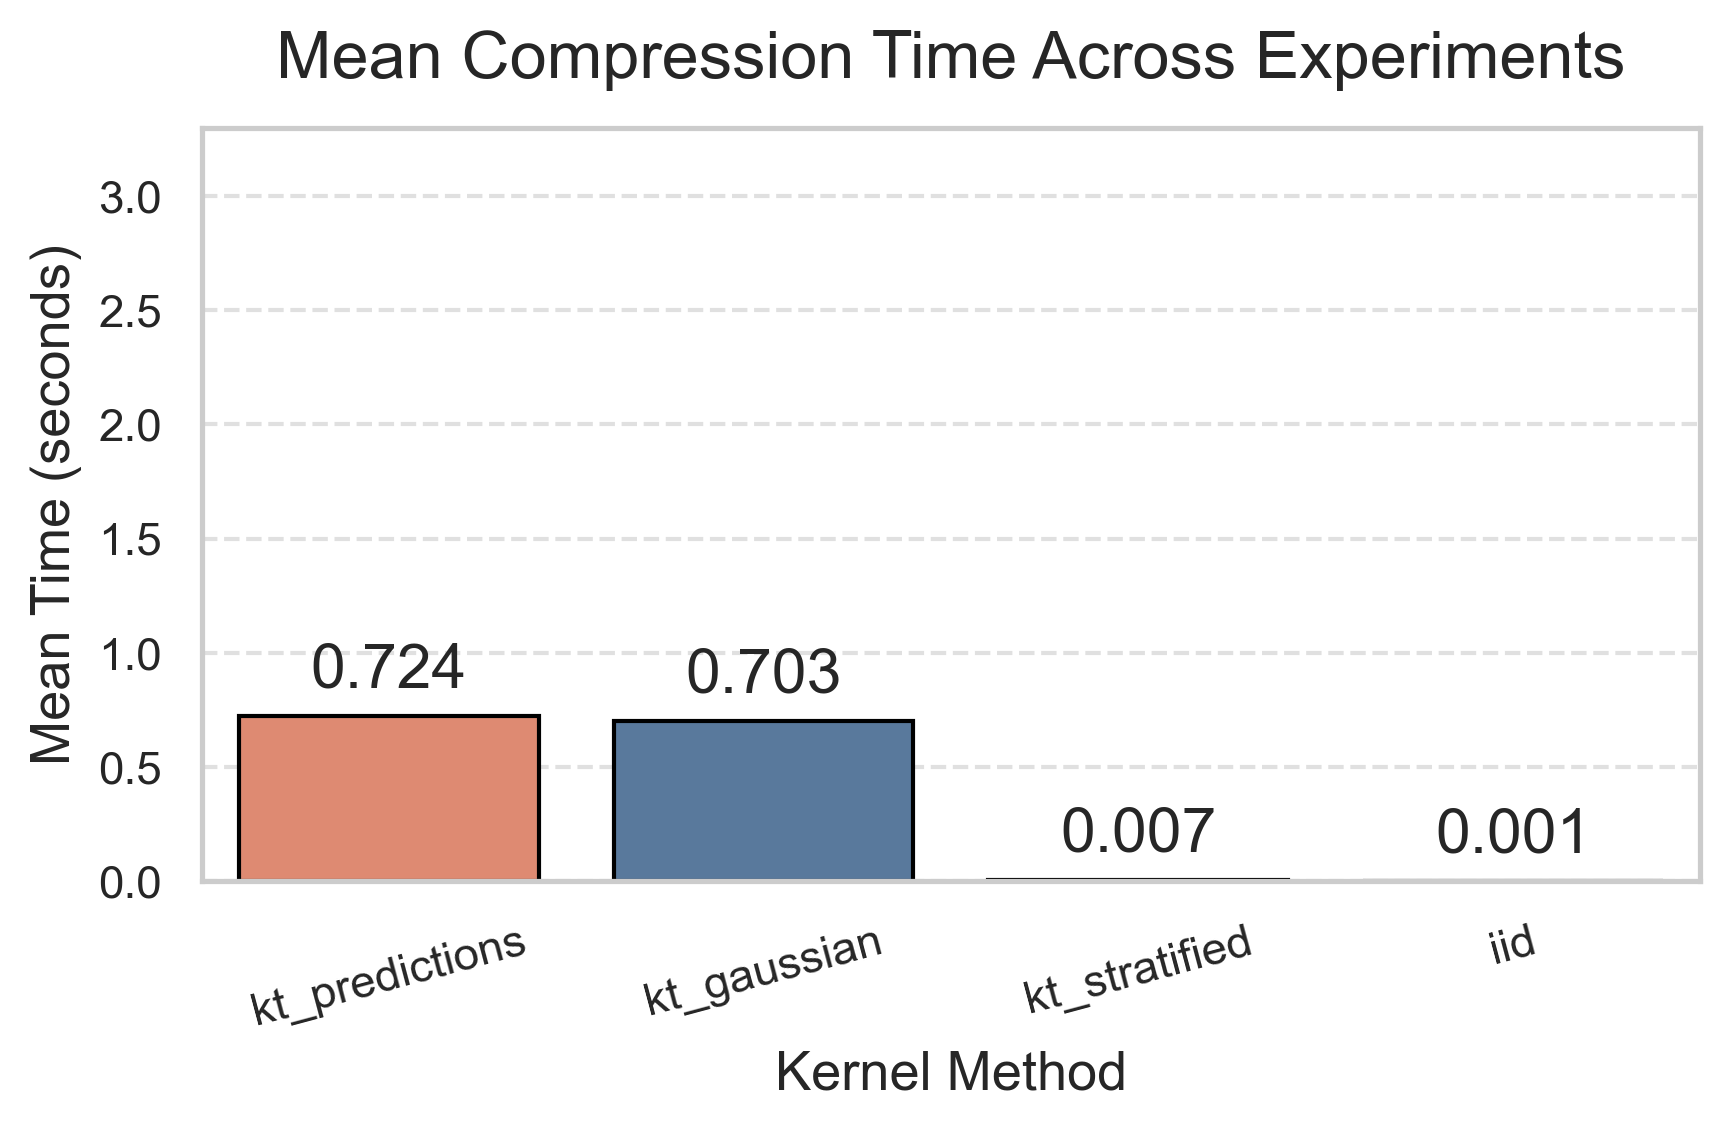

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Data ---
results_aggregated = pd.read_csv("../package_metadata/results_aggregation.csv")

all_methods = [
    'kt_gaussian',
    'kt_predictions',
    'kt_stratified',
    'iid'
]

results_aggregated = results_aggregated[
    results_aggregated['method_total'].isin(all_methods)
]

results_aggregated = results_aggregated[
    (results_aggregated['model_name'] == 'nn') &
    (results_aggregated['explainer_total'].isin(
        ['expected_gradients', 'sage_permutation']
    ))
]

plot_data = (
    results_aggregated
    .groupby('method_total', as_index=False)['compression_time_mean']
    .mean()
    .sort_values(by='compression_time_mean', ascending=False)
)

# --- Style ---
sns.set_theme(
    style="whitegrid",
    font_scale=1.2
)

method_colors = {
    "kt_gaussian": "#4E79A7",
    "kt_stratified": "#81b29a",
    "kt_predictions": "#f08060",
    "iid": "#1F51FF",
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

sns.barplot(
    data=plot_data,
    x="method_total",
    y="compression_time_mean",
    palette=method_colors,
    edgecolor="black",
    linewidth=1,
    ax=ax
)

# --- Labels ---
ax.set_title(
    "Mean Compression Time Across Experiments",
    fontsize=16,
    pad=12
)
ax.set_xlabel("Kernel Method", fontsize=13)
ax.set_ylabel("Mean Time (seconds)", fontsize=13)

ax.tick_params(axis="x", rotation=15)
ax.tick_params(axis="both", labelsize=11)

# --- Grid ---
ax.grid(axis="y", linestyle="--", alpha=0.6)
ax.grid(axis="x", visible=False)

ax.set_ylim(0, 3.3)

# --- Annotations ---
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=4,
        fontsize=15
    )

# --- Layout & Save ---
plt.tight_layout()
plt.savefig(
    "Image21/compression_time_custom_compared.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight"
)


# Image23 - full grid for baseleine methods --a fter cell with Image14

In [18]:
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from matplotlib.backends.backend_pdf import PdfPages

output_dir = "./Image23"
os.makedirs(output_dir, exist_ok=True)

row_metrics = [
    "mae_mean",
    "mae_std",
    "top_k_mean",
    "top_k_std",
    "mmd_mean"
]

methods_to_plot = [
    'kt_matern', 'stein_thinning', 'arfpy', 'influence',
]

tasks = ["regression", "classification"]

palette = plt.get_cmap("tab10")
method_colors = {
    "kt_matern": "#59A14F",
    "arfpy": "#FF7DB0",
    "stein_thinning": "#B8DB80",
    "influence": "#5459AC",
}

task_hatch = {
    "regression": None,
    "classification": "//",
}

method_labels = {
    "kt_matern": "KT (Matérn)",
    "stein_thinning": "Stein Thinning",
    "arfpy": "ARF",
    "influence": "Influence",
}

explainer_labels = {
    "expected_gradients": "Expected Gradients",
    "sage_permutation": "SAGE (Permutation)",
    "shap_kernel": "SHAP (Kernel)",
    "shapiq_kernel": "SHAP-IQ (Kernel)",
}

metric_ylabels = {
    "mae_mean": "MAE Reduction (%)",
    "mae_std": "MAE Std Reduction (%)",
    "top_k_mean": "Top-k Improvement (%)",
    "top_k_std": "Top-k Std Change (%)",
}

edgecolor = "#333333"
zero_tol = 1e-12
label_min_abs = 0.05

explainers = [e for e in explainer_labels if e in results_with_improvements["explainer_total"].unique()]
models = sorted(results_with_improvements["model_name"].unique())

n_rows = len(row_metrics)
n_cols = len(explainers)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 18), sharex=True)

if n_rows == 1: axes = axes.reshape(1, -1)
if n_cols == 1: axes = axes.reshape(-1, 1)

bar_group_width = 0.85
total_bars = len(methods_to_plot) * len(tasks)
bar_w = bar_group_width / total_bars

for row_idx, metric in enumerate(row_metrics):
    pct_col = f"{metric}_pct_reduction"
    flip_sign = ("top_k" in metric and "mean" in metric) 
    
    dfs = []
    for method in methods_to_plot:
        sub = results_with_improvements[results_with_improvements["method_total"] == method]
        if sub.empty:
            continue
        
        df_method = (
            sub.groupby(["task", "model_name", "explainer_total"])[[pct_col]]
            .mean()
            .mean(axis=1)
            .reset_index(name="mean_improvement")
        )
        df_method["method_total"] = method
        dfs.append(df_method)

    if not dfs:
        continue

    df_all = pd.concat(dfs, ignore_index=True)
    
    if flip_sign:
        df_all["mean_improvement"] *= -1

    row_vals = df_all["mean_improvement"].values
    y_min = min(0, np.min(row_vals) * 1.1)
    y_max = np.max(row_vals) * 1.15
    if y_max == 0: y_max = 1.0

    for col_idx, explainer in enumerate(explainers):
        ax = axes[row_idx, col_idx]
        sub = df_all[df_all["explainer_total"] == explainer]
        
        x = np.arange(len(models))
        bar_i = 0
        
        for task in tasks:
            for method in methods_to_plot:
                tmp = sub[(sub["method_total"] == method) & (sub["task"] == task)]
                values = [
                    tmp.loc[tmp["model_name"] == m, "mean_improvement"].values[0]
                    if m in tmp["model_name"].values else 0.0
                    for m in models
                ]
                
                xpos = x + (bar_i - (total_bars - 1) / 2) * bar_w
                
                bars = ax.bar(
                    xpos, values, bar_w,
                    color=method_colors[method],
                    hatch=task_hatch[task],
                    edgecolor=edgecolor,
                    linewidth=0.8,
                )
                
                for b in bars:
                    h = b.get_height()
                    if abs(h) < label_min_abs:
                        continue
                        
                    fs = 7 
                    ax.text(
                        b.get_x() + b.get_width()/2,
                        h + (0.05 * y_max if h >= 0 else -0.15 * abs(y_min)),
                        f"{h:.1f}",
                        ha="center",
                        va="bottom" if h >= 0 else "top",
                        fontsize=fs,
                        rotation=90 
                    )
                
                bar_i += 1

        ax.set_ylim(y_min, y_max)
        ax.grid(axis="y", linestyle="--", alpha=0.4)
        
        if col_idx == 0:
            ax.set_ylabel(metric_ylabels.get(metric, metric), fontsize=13, fontweight='bold')
        
        if row_idx == 0:
            ax.set_title(explainer_labels[explainer], fontsize=15, fontweight='bold', pad=15)
            
        if row_idx == n_rows - 1:
            ax.set_xticks(x)
            ax.set_xticklabels(models, fontsize=11, rotation=0)
        else:
            ax.tick_params(labelbottom=False)

legend_handles = [
    Patch(facecolor=method_colors[m], edgecolor=edgecolor, label=method_labels[m])
    for m in methods_to_plot
] + [
    Patch(facecolor="white", edgecolor=edgecolor, hatch=task_hatch[t], label=t.capitalize())
    for t in tasks
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.01),
    ncol=len(legend_handles),
    frameon=False,
    fontsize=14
)

# Title
plt.suptitle("Compression Methods Performance: MAE & Top-k Analysis", fontsize=20, y=0.99)

plt.tight_layout()
plt.subplots_adjust(bottom=0.08, top=0.94)

pdf_path = os.path.join(output_dir, "grid_4x4_different_baselines_comparison.pdf")
plt.savefig(pdf_path, dpi=300, format="pdf")
plt.close(fig)

# Image24

/var/folders/rv/f71wkbsd1qs63ff8371lyjx40000gn/T/ipykernel_2008/2836599627.py:53: UserWarning: 
The markers list has fewer values (1) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(


Plot saved to Image24/compression_time_baselines_vs_compression_size.pdf


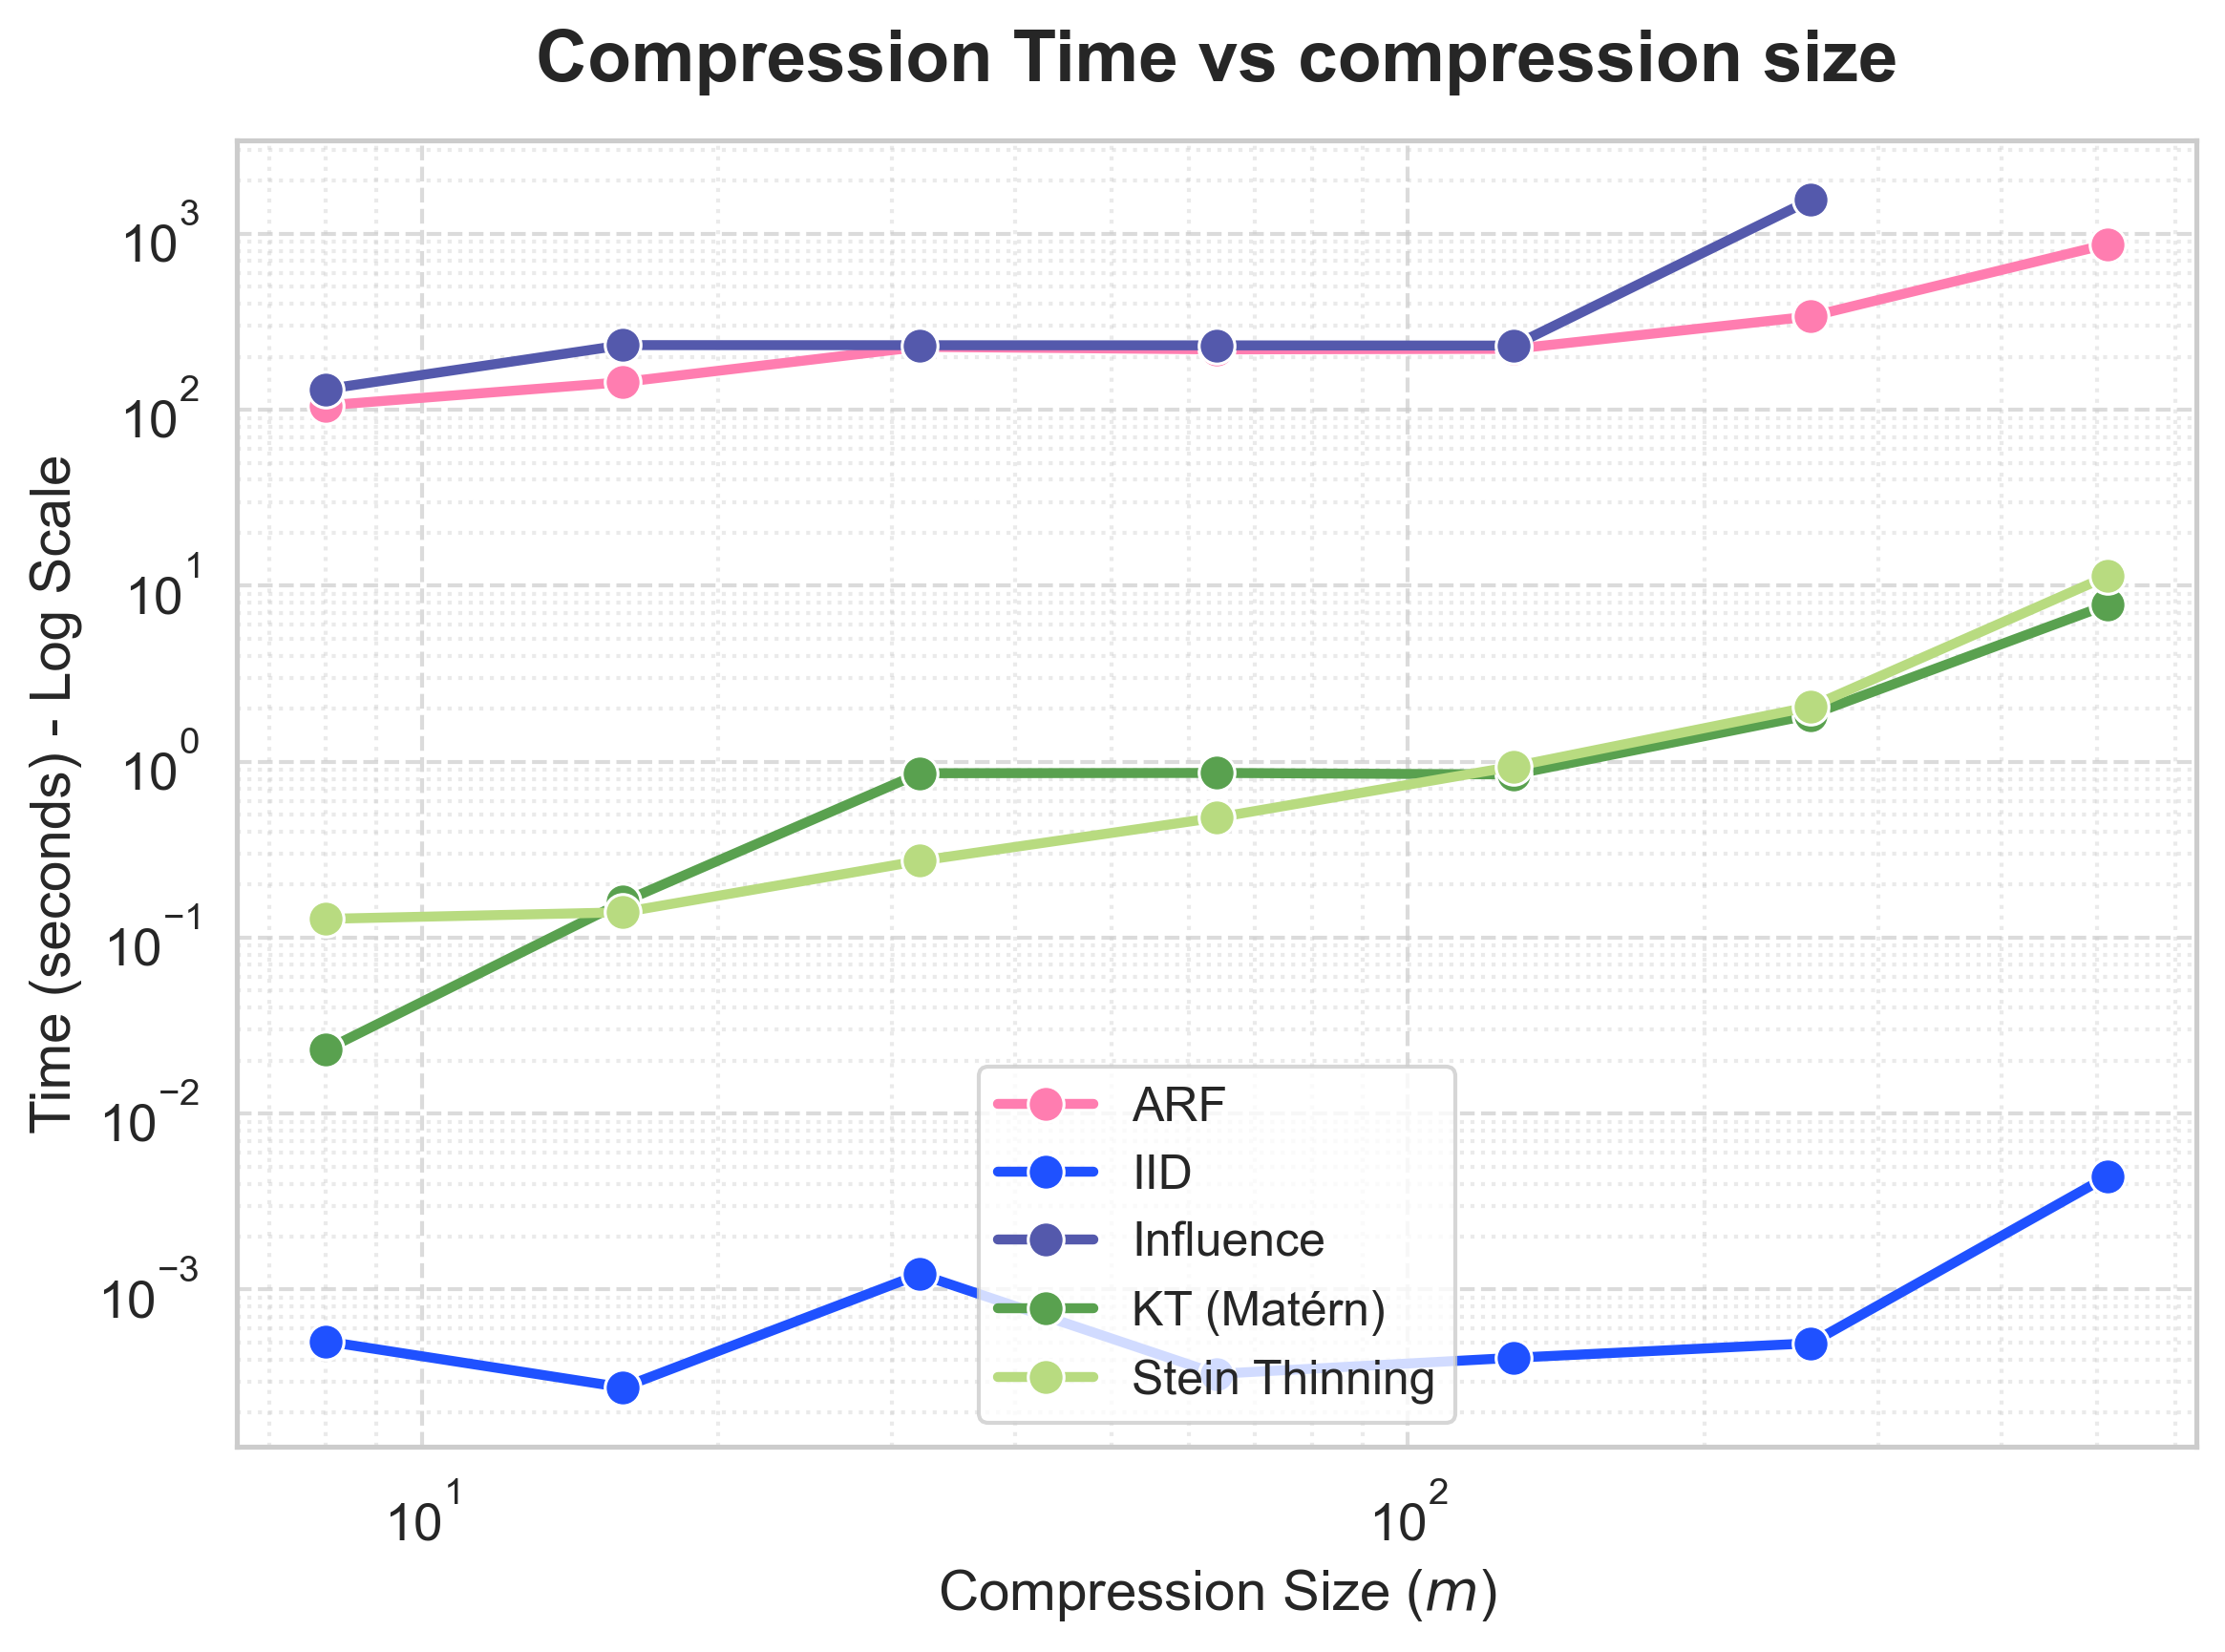

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

output_dir = "Image24"
os.makedirs(output_dir, exist_ok=True)

method_colors = {
    "kt_matern": "#59A14F",
    "arfpy": "#FF7DB0",
    "stein_thinning": "#B8DB80",
    "influence": "#5459AC",
    "iid": "#1F51FF",
}

method_labels = {
    "kt_matern": "KT (Matérn)",
    "arfpy": "ARF",
    "stein_thinning": "Stein Thinning",
    "influence": "Influence",
    "iid": "IID",
}

results_aggregated = pd.read_csv("../package_metadata/results_aggregation.csv")

all_methods = [
    'kt_matern',
    'arfpy',
    'stein_thinning',
    'influence',
    'iid'
]

df = results_aggregated[results_aggregated['method_total'].isin(all_methods)].copy()

df = df[
    (df['model_name'] == 'nn') &
    (df['explainer_total'].isin(['expected_gradients', 'sage_permutation']))
]

plot_data = (
    df.groupby(['method_total', 'size'], as_index=False)['compression_time_mean']
    .mean()
)

plot_data = plot_data.sort_values(by=['method_total', 'size'])

sns.set_theme(style="whitegrid", font_scale=1.2)

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

sns.lineplot(
    data=plot_data,
    x="size",
    y="compression_time_mean",
    hue="method_total",
    style="method_total",
    palette=method_colors,
    markers='o',
    dashes=False,    
    linewidth=2.5,
    markersize=9,
    ax=ax
)

ax.set_yscale("log")
ax.set_xscale("log")

ax.set_title("Compression Time vs compression size", fontsize=18, weight='bold', pad=15)
ax.set_xlabel("Compression Size ($m$)", fontsize=14)
ax.set_ylabel("Time (seconds) - Log Scale", fontsize=14)

ax.grid(True, which="major", linestyle="--", alpha=0.7)
ax.grid(True, which="minor", linestyle=":", alpha=0.4)

handles, labels = ax.get_legend_handles_labels()
new_labels = [method_labels.get(label, label) for label in labels]
ax.legend(
    handles, 
    new_labels, 
    title=None, 
    fontsize=12,
    frameon=True,
    loc='best'
)

plt.tight_layout()

save_path = os.path.join(output_dir, "compression_time_baselines_vs_compression_size.pdf")
plt.savefig(save_path, format="pdf", dpi=300, bbox_inches="tight")

print(f"Plot saved to {save_path}")
plt.show()

Plot saved to Image24/compression_time_vs_n_samples_test.pdf
Plot saved to Image24/compression_time_vs_n_features.pdf


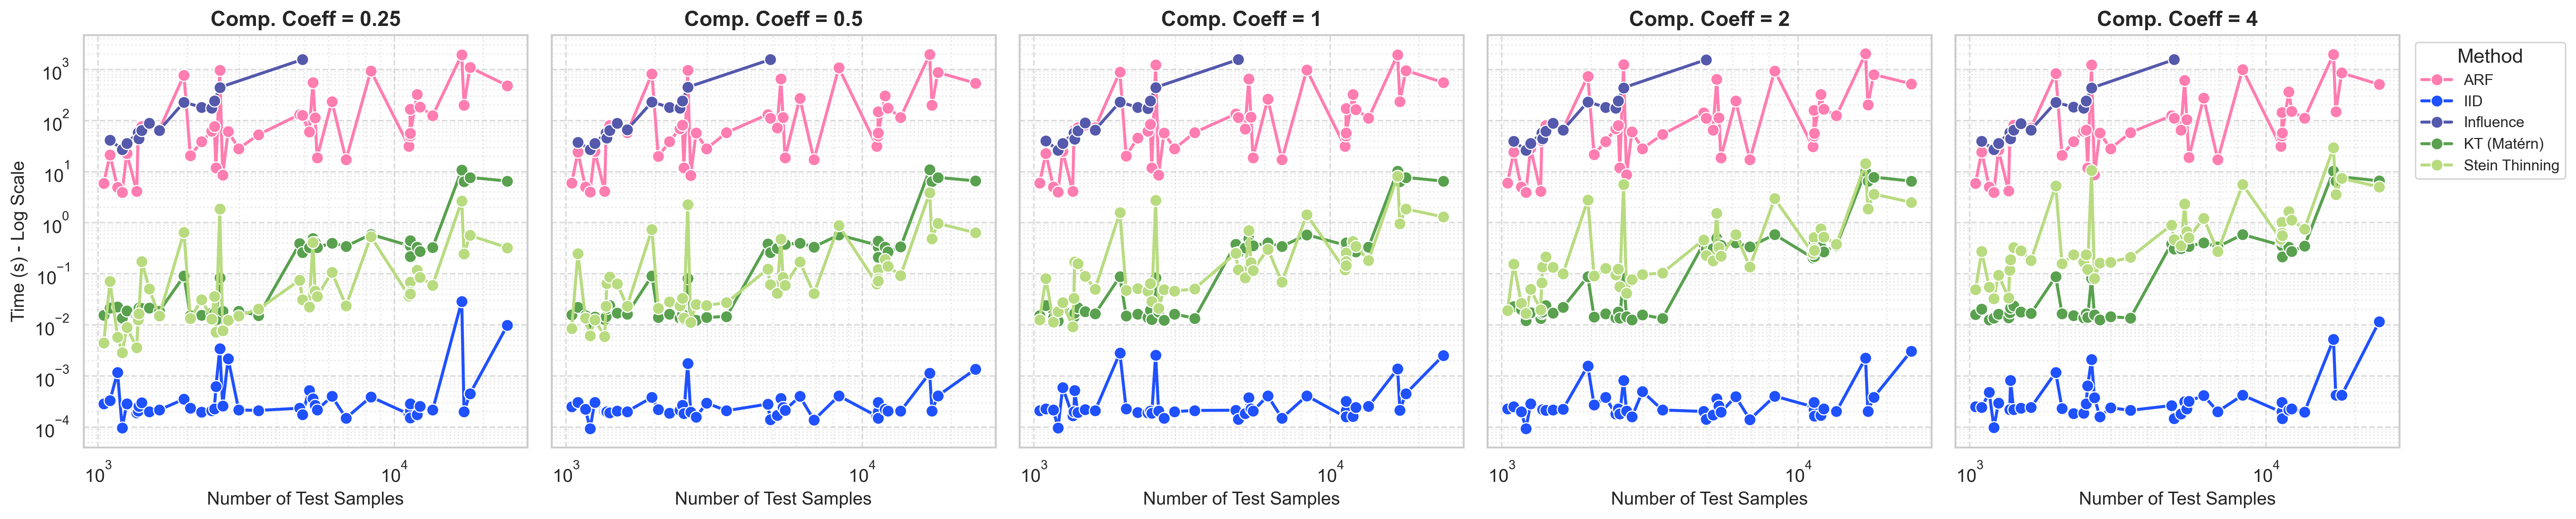

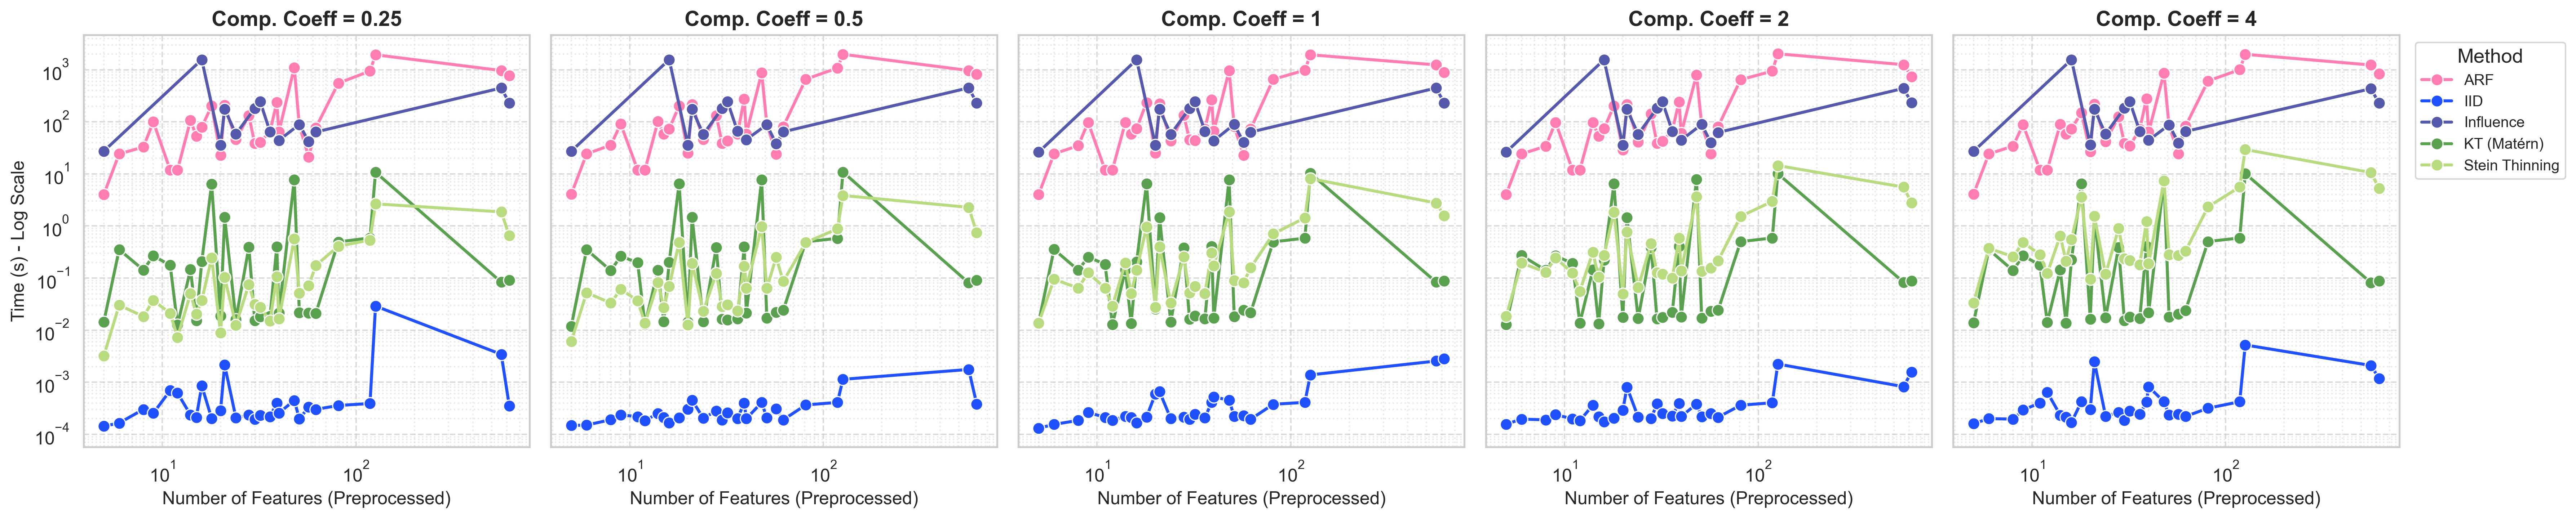

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

output_dir = "Image24"
os.makedirs(output_dir, exist_ok=True)

method_colors = {
    "kt_matern": "#59A14F",
    "arfpy": "#FF7DB0",
    "stein_thinning": "#B8DB80",
    "influence": "#5459AC",
    "iid": "#1F51FF",
}

method_labels = {
    "kt_matern": "KT (Matérn)",
    "arfpy": "ARF",
    "stein_thinning": "Stein Thinning",
    "influence": "Influence",
    "iid": "IID",
}

results_aggregated = pd.read_csv("../package_metadata/results_aggregation.csv")

all_methods = [
    'kt_matern',
    'arfpy',
    'stein_thinning',
    'influence',
    'iid'
]

df_main = results_aggregated[results_aggregated['method_total'].isin(all_methods)].copy()
df_main = df_main[
    (df_main['model_name'] == 'nn') &
    (df_main['explainer_total'].isin(['expected_gradients', 'sage_permutation']))
]

coeffs = [0.25, 0.5, 1, 2, 4]

sns.set_theme(style="whitegrid", font_scale=1.1)

def create_row_plot(x_col, x_label, file_suffix):
    """
    Creates a figure with 5 subplots in a row, one for each compression coefficient.
    """
    fig, axes = plt.subplots(1, 5, figsize=(24, 5), dpi=300, sharey=True)
    
    for i, coeff in enumerate(coeffs):
        ax = axes[i]
        
        df_subset = df_main[df_main['compression_coefficient'] == coeff].copy()
        
        plot_data = (
            df_subset.groupby(['method_total', x_col], as_index=False)['compression_time_mean']
            .mean()
        )
        plot_data = plot_data.sort_values(by=['method_total', x_col])
        
        if plot_data.empty:
            ax.set_title(f"Coeff: {coeff} (No Data)")
            continue

        sns.lineplot(
            data=plot_data,
            x=x_col,
            y="compression_time_mean",
            hue="method_total",
            style=None,
            palette=method_colors,
            markers=True,
            marker='o',
            dashes=False,
            linewidth=2,
            markersize=8,
            ax=ax,
            legend=(i == 4)
        )
        
        ax.set_yscale("log")
        ax.set_xscale("log")
        
        ax.set_title(f"Comp. Coeff = {coeff}", fontsize=14, weight='bold')
        ax.set_xlabel(x_label, fontsize=12)
        
        if i == 0:
            ax.set_ylabel("Time (s) - Log Scale", fontsize=12)
        else:
            ax.set_ylabel("")
            
        ax.grid(True, which="major", linestyle="--", alpha=0.7)
        ax.grid(True, which="minor", linestyle=":", alpha=0.4)
        
        if i == 4:
            handles, labels = ax.get_legend_handles_labels()
            new_labels = [method_labels.get(label, label) for label in labels]
            ax.legend(
                handles, 
                new_labels, 
                title="Method",
                fontsize=10,
                loc='upper left',
                bbox_to_anchor=(1.02, 1) 
            )

    plt.tight_layout()
    save_path = os.path.join(output_dir, f"compression_time_vs_{file_suffix}.pdf")
    plt.savefig(save_path, format="pdf", dpi=300, bbox_inches="tight")
    print(f"Plot saved to {save_path}")

# --- Generate Plot 1: X = n_samples_test ---
create_row_plot(
    x_col="n_samples_test", 
    x_label="Number of Test Samples", 
    file_suffix="n_samples_test"
)

# --- Generate Plot 2: X = n_features_after_preprocessing ---
create_row_plot(
    x_col="n_features_after_preprocessing", 
    x_label="Number of Features (Preprocessed)", 
    file_suffix="n_features"
)

plt.show()

Plot saved to Image24/grid_25_plots_n_samples_test.pdf
Plot saved to Image24/grid_25_plots_n_features.pdf


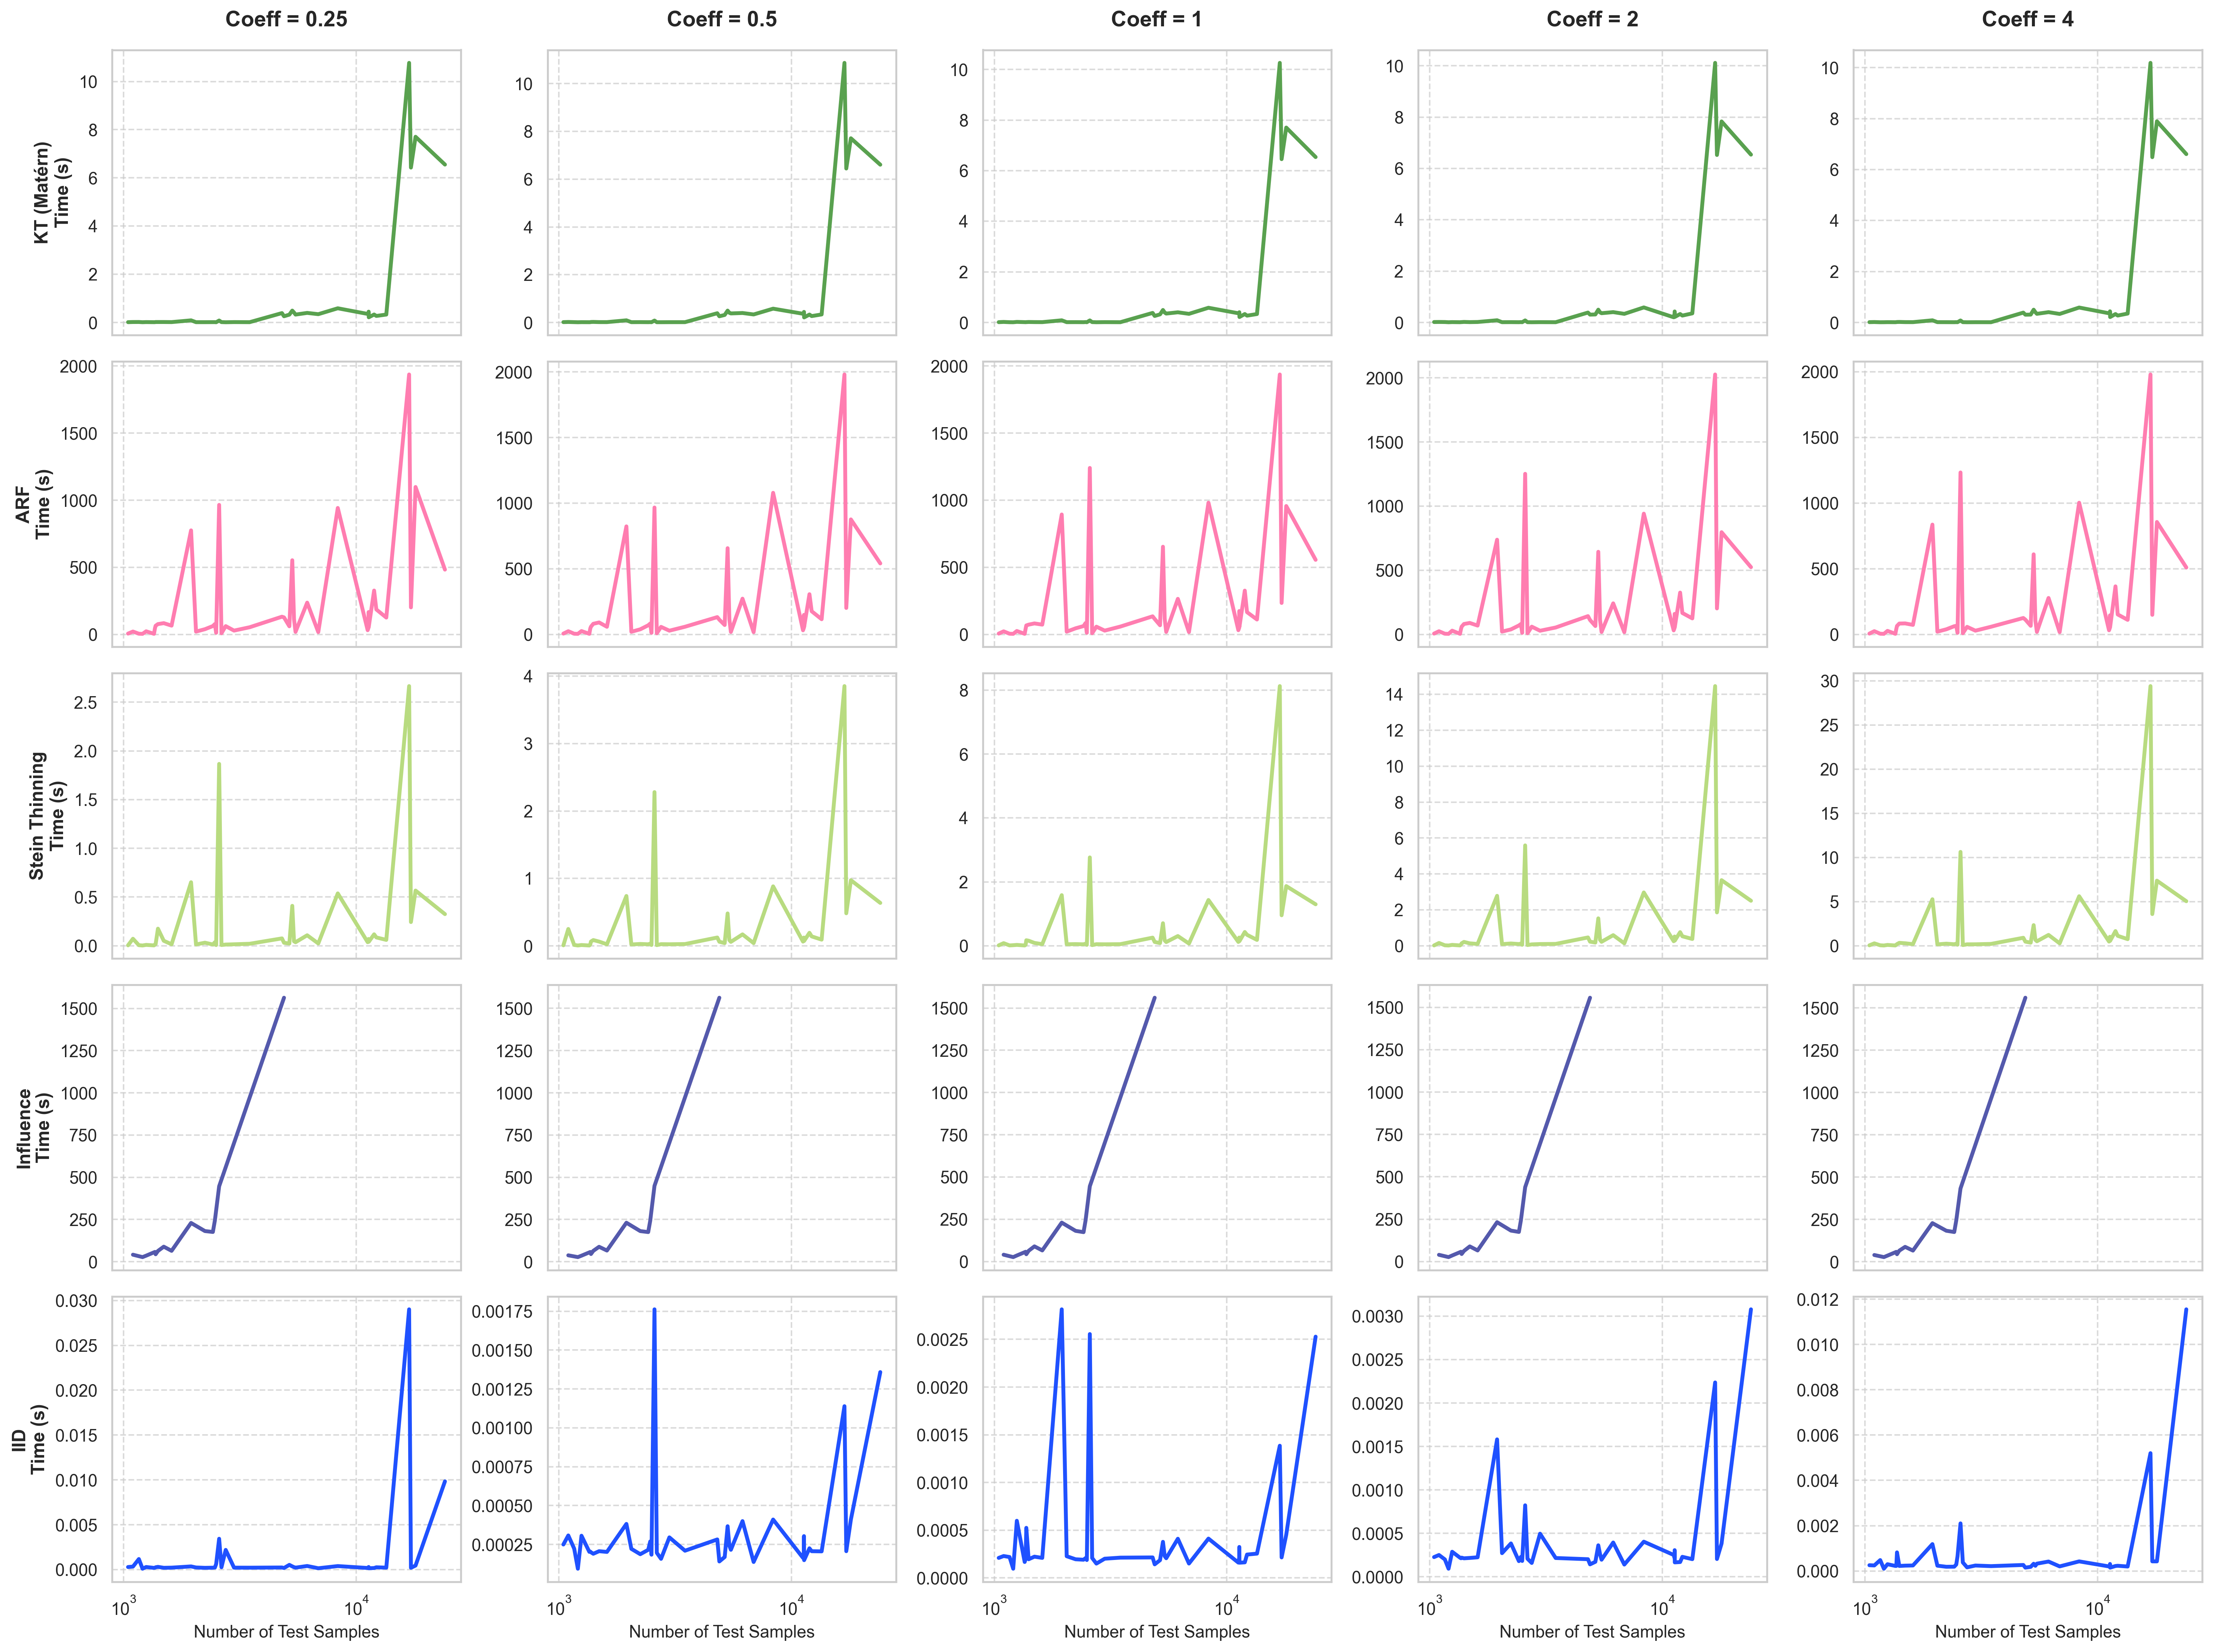

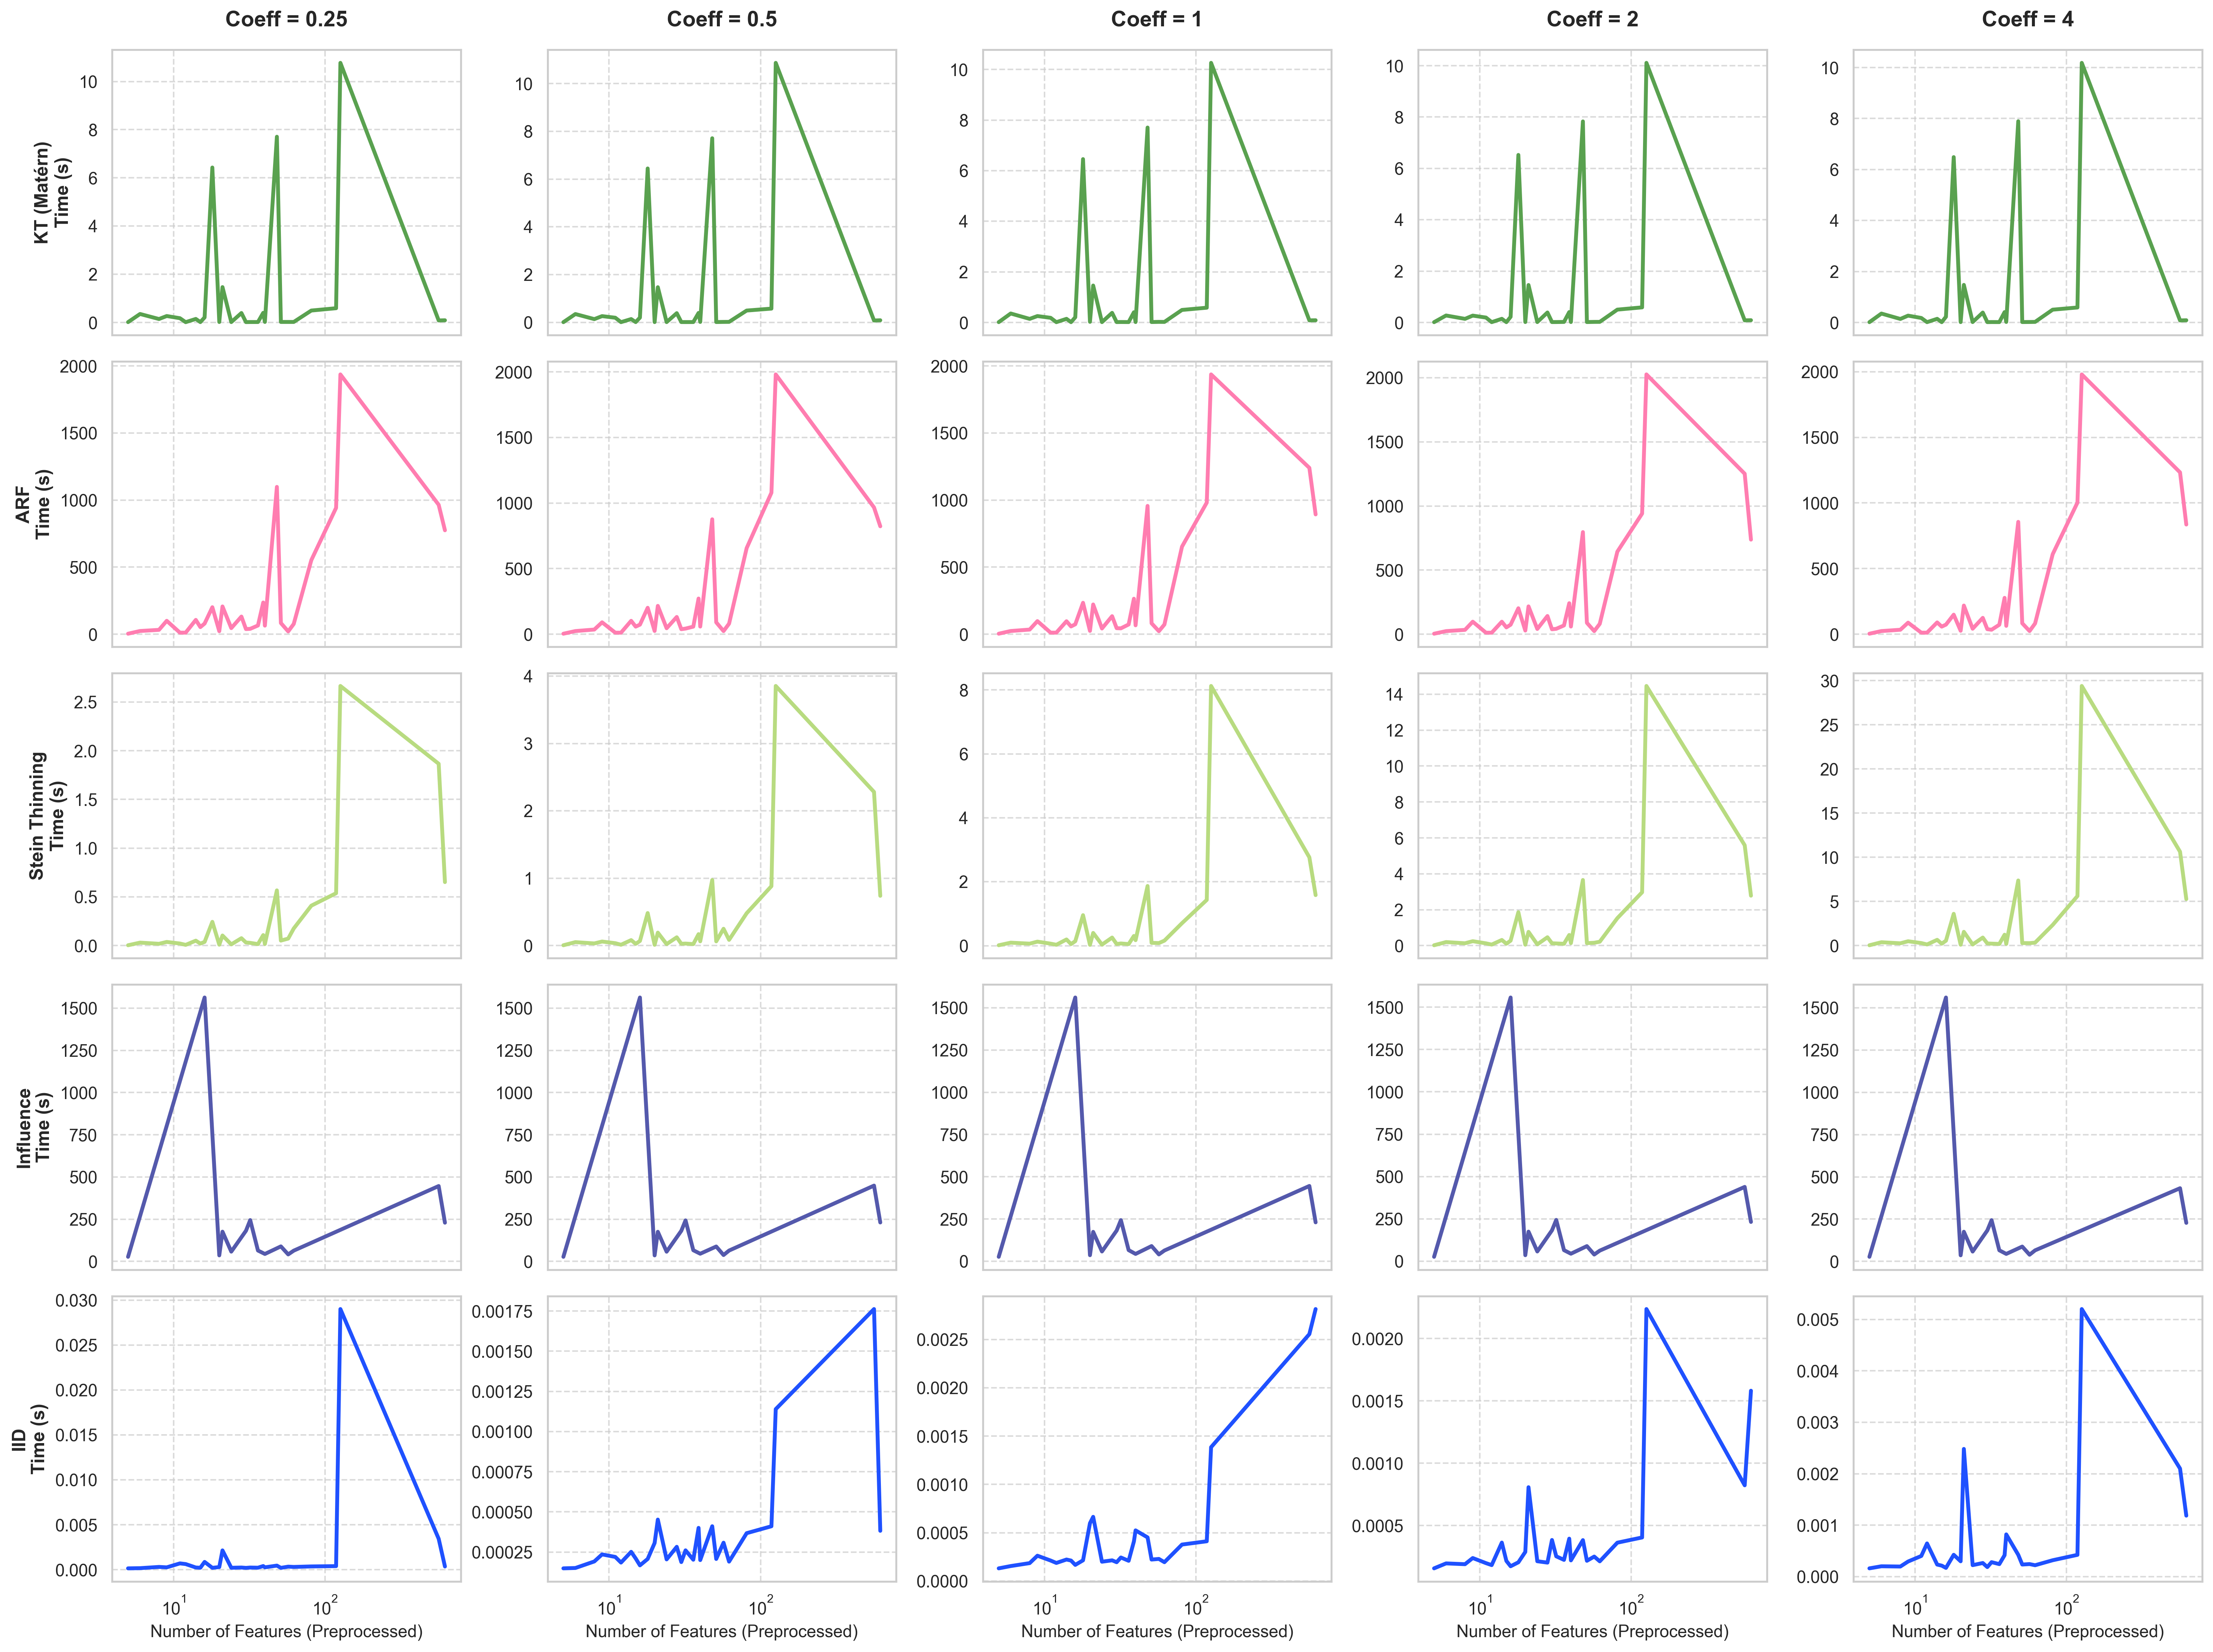

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

output_dir = "Image24"
os.makedirs(output_dir, exist_ok=True)

method_colors = {
    "kt_matern": "#59A14F",
    "arfpy": "#FF7DB0",
    "stein_thinning": "#B8DB80",
    "influence": "#5459AC",
    "iid": "#1F51FF",
}

method_labels = {
    "kt_matern": "KT (Matérn)",
    "arfpy": "ARF",
    "stein_thinning": "Stein Thinning",
    "influence": "Influence",
    "iid": "IID",
}

# Load data (assuming the path is correct in your environment)
results_aggregated = pd.read_csv("../package_metadata/results_aggregation.csv")

all_methods = [
    'kt_matern',
    'arfpy',
    'stein_thinning',
    'influence',
    'iid'
]

# Filter main dataframe
df_main = results_aggregated[results_aggregated['method_total'].isin(all_methods)].copy()
df_main = df_main[
    (df_main['model_name'] == 'nn') &
    (df_main['explainer_total'].isin(['expected_gradients', 'sage_permutation']))
]

coeffs = [0.25, 0.5, 1, 2, 4]

sns.set_theme(style="whitegrid", font_scale=1.0)

def create_grid_plot(x_col, x_label, file_suffix):
    """
    Creates a figure with 25 subplots (5 rows x 5 columns).
    Rows: Methods
    Columns: Compression Coefficients
    """
    # Create 5x5 grid
    # sharex='col': share X axis within columns
    # sharey='row': share Y axis within rows (optional, allows comparing specific method across coeffs)
    fig, axes = plt.subplots(5, 5, figsize=(20, 15), dpi=300, sharex=True, sharey=False)
    
    # Loop through methods (Rows)
    for row_idx, method_key in enumerate(all_methods):
        
        # Loop through coefficients (Columns)
        for col_idx, coeff in enumerate(coeffs):
            ax = axes[row_idx, col_idx]
            
            # Filter data for this specific cell (Method + Coefficient)
            df_subset = df_main[
                (df_main['method_total'] == method_key) & 
                (df_main['compression_coefficient'] == coeff)
            ].copy()
            
            # Aggregate mean time
            plot_data = (
                df_subset.groupby(['method_total', x_col], as_index=False)['compression_time_mean']
                .mean()
            )
            plot_data = plot_data.sort_values(by=x_col)
            
            # Handle empty data
            if plot_data.empty:
                ax.text(0.5, 0.5, "No Data", ha='center', va='center')
                continue

            # Plot the line (No markers)
            sns.lineplot(
                data=plot_data,
                x=x_col,
                y="compression_time_mean",
                color=method_colors[method_key],
                linewidth=2.5,
                ax=ax,
                marker=None  # Explicitly remove markers
            )
            
            # Set X-axis to log scale
            ax.set_xscale("log")
            
            # Grid styling
            ax.grid(True, which="major", linestyle="--", alpha=0.7)
            
            # --- Labeling ---
            
            # Set Column Titles (Coefficients) only on the top row
            if row_idx == 0:
                ax.set_title(f"Coeff = {coeff}", fontsize=14, weight='bold', pad=15)
            
            # Set Row Labels (Method Names) on the left side
            if col_idx == 0:
                ax.set_ylabel(f"{method_labels[method_key]}\nTime (s)", fontsize=12, weight='bold')
            else:
                ax.set_ylabel("") # Hide Y label for inner plots

            # Set X labels only on the bottom row
            if row_idx == 4:
                ax.set_xlabel(x_label, fontsize=11)
            else:
                ax.set_xlabel("")

    plt.tight_layout()
    
    # Save output
    save_path = os.path.join(output_dir, f"grid_25_plots_{file_suffix}.pdf")
    plt.savefig(save_path, format="pdf", dpi=300, bbox_inches="tight")
    print(f"Plot saved to {save_path}")

# --- Generate Plot 1: X = n_samples_test ---
create_grid_plot(
    x_col="n_samples_test", 
    x_label="Number of Test Samples", 
    file_suffix="n_samples_test"
)

# --- Generate Plot 2: X = n_features_after_preprocessing ---
create_grid_plot(
    x_col="n_features_after_preprocessing", 
    x_label="Number of Features (Preprocessed)", 
    file_suffix="n_features"
)

plt.show()